Using a subsample of r in the model eleviated some problems, like initialization errors of the gp when using (0,0,0).
Also fixed the memory error during gp calculation.

How to sample the other parameters in the model?

Finding interpolation rutine implemented in jax.
Current one only supports linear interpolation, while cubic would be prefered.
Maybe use jax_cosmo.scipy.interpolate. Suggestions?

Memory problems when using a 200x200 image. 100x100 works for now.
Currently testing our older implementation on bigger grids, current maximum was 500x500 grid with a runtime of 12-20 minutes. testing of larger grids still in progress.
This was with only one free parameter.


    #sigma_p = numpyro.sample("sigma_p", dist.HalfNormal(1.))
    #length_scale_p = numpyro.sample("length_scale_p", dist.HalfNormal(0.1))

    #add log error in observed image do same in model log image sample log error obver gaussian distribution done
    # add plot loss over svi steps done
    # add predictive
    # add deterministic


    # do longer runs to see if std converges and larger noise try up to 50%
    # add deterministic to sb and calculate mean/std
    # try different inital p function
    # observe_image - mean predition / std_pred instead of residual

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import jax.numpy as jnp
from jax import grad, vmap
from matplotlib.colors import LogNorm
import jax
import random

from JAX_Deprojection import surface_brightness as sb
from JAX_Deprojection import density_distribution as den
import jax
import numpyro
import numpyro.distributions as dist
from tinygp import kernels, GaussianProcess
from numpyro.infer.autoguide import AutoNormal, AutoDelta
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
from jax.scipy.interpolate import RegularGridInterpolator

In [4]:

'''
s_def = 1. 

e_k_def = 0.0 
e_d_def = 0.0

p_a_def = 0.00160907
p_b_def = -0.02122767
p_c_def = 0.07711992
p_d_def = 0.54249868

q_a_def = 0.0
q_b_def = 0.0
q_c_def = 0.0
q_d_def = 0.6

a_def = 2.
b_def = 4.
rho0_def = 0.001
i_def = 0.
phi_def = 0.
theta_def = 0.

size = 100
extent = 5
extents = [-extent, extent,-extent, extent]
'''

'\ns_def = 1. \n\ne_k_def = 0.0 \ne_d_def = 0.0\n\np_a_def = 0.00160907\np_b_def = -0.02122767\np_c_def = 0.07711992\np_d_def = 0.54249868\n\nq_a_def = 0.0\nq_b_def = 0.0\nq_c_def = 0.0\nq_d_def = 0.6\n\na_def = 2.\nb_def = 4.\nrho0_def = 0.001\ni_def = 0.\nphi_def = 0.\ntheta_def = 0.\n\nsize = 100\nextent = 5\nextents = [-extent, extent,-extent, extent]\n'

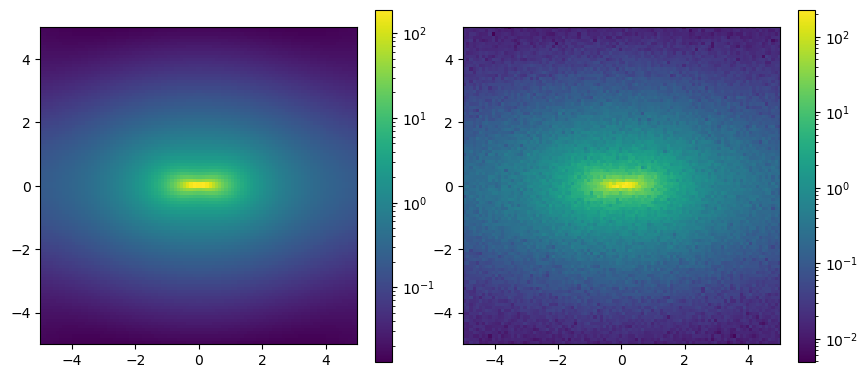

In [5]:
def create_dummy_image(e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def,error_fraction):

    size = 100
    extent = 5
    extents = [-extent, extent,-extent, extent]

    fig, (ax1,ax2) = plt.subplots(1, 2,figsize=(10, 10))

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
    im1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(), origin='lower',extent = extents)
    fig.colorbar(im1,ax=ax1,fraction = 0.05)

    key = jax.random.PRNGKey(42)
    noise = jax.random.normal(key, shape=sb_1.data.shape) * (error_fraction * sb_1.data)
    noisy_data = jnp.clip(sb_1.data + noise, 1e-6, None)

    im2 = ax2.imshow(noisy_data.T, norm=colors.LogNorm(), origin='lower',extent = extents)
    fig.colorbar(im2,ax=ax2,fraction = 0.05)


    return noisy_data, extents,size

s_def = 1. 

e_k_def = 0.0 
e_d_def = 0.0

q_a_def = 0.0
q_b_def = 0.0
q_c_def = 0.0
q_d_def = 0.6

a_def = 2.
b_def = 4.
rho0_def = 1.
i_def = 0.
phi_def = 0.
theta_def = 0.

p_input_params=[]
p_a_def = 0.00914918
p_b_def = -0.12086247
p_c_def = 0.44761072
p_d_def = 0.07762238
p1 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p1)

poly_extreme_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,p_a_def,p_b_def,p_c_def,p_d_def,
                                                      rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)


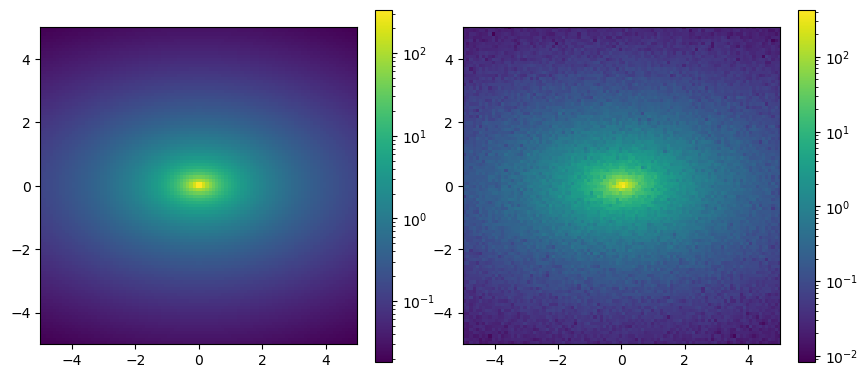

In [6]:
p_a_def = 0.00160907
p_b_def = -0.02122767
p_c_def = 0.07711992
p_d_def = 0.54249868
p2 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p2)

poly_flat_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,p_a_def,p_b_def,p_c_def,p_d_def,
                                                   rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

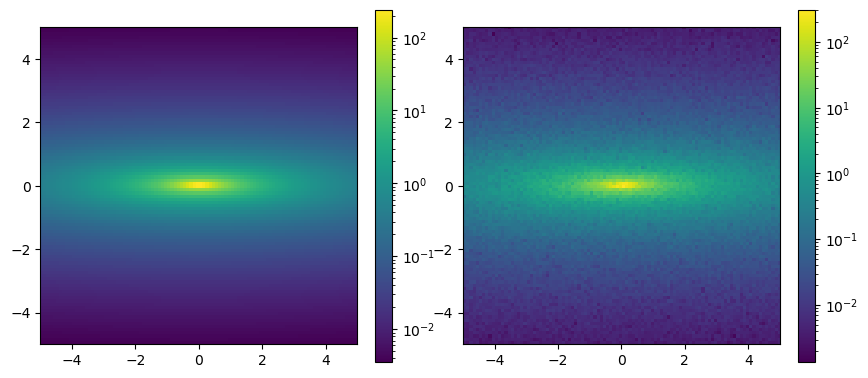

In [7]:
p_a_def = 0.0
p_b_def = 0.0
p_c_def = 0.0
p_d_def = 0.2
p3 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p3)

const_low_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,p_a_def,p_b_def,p_c_def,p_d_def,
                                                   rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

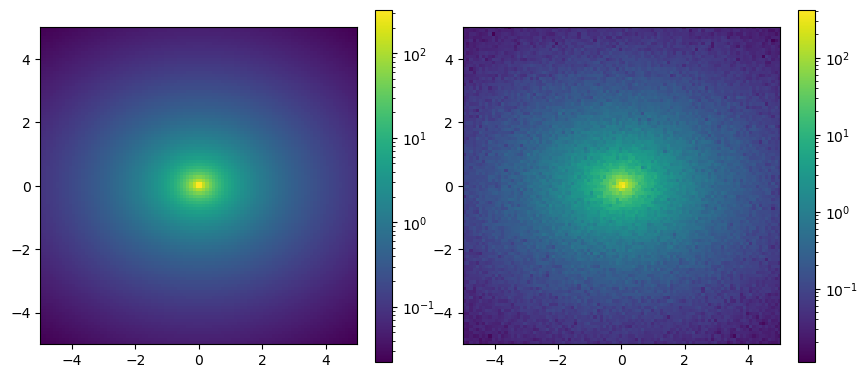

In [8]:
p_a_def = 0.0
p_b_def = 0.0
p_c_def = 0.0
p_d_def = 0.8
p4 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p4)

const_high_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,p_a_def,p_b_def,p_c_def,p_d_def,
                                                    rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

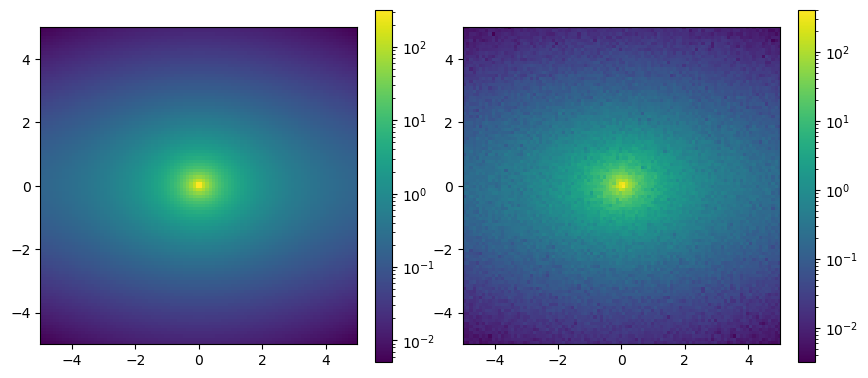

In [9]:
p_a_def = 0.
p_b_def = 0.
p_c_def = -0.088
p_d_def = 0.9
p5 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p5)
linear_decline_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,p_a_def,p_b_def,p_c_def,p_d_def,
                                                        rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

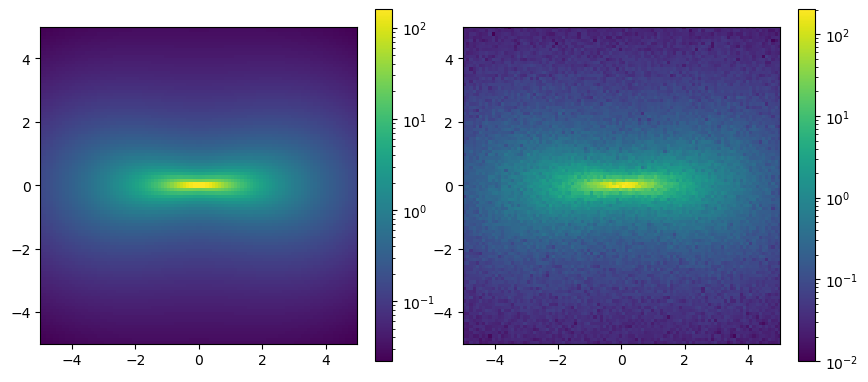

In [10]:
p_a_def = 0.
p_b_def = 0.
p_c_def = 0.088
p_d_def = 0.1
p6 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p6)

linear_incline_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,p_a_def,p_b_def,p_c_def,p_d_def,
                                                        rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

In [11]:
from JAX_Deprojection import utils

numpyro.enable_validation(is_validate=True)

# create r array smallest smaller than grid biggest bigger with ~100 points
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    q0 = numpyro.sample('q0', dist.Uniform(0.001,1.)) # i.e. = q(0)
    q5 = numpyro.sample('q5', dist.Uniform(0.001,1.)) # i.e. = q(5)
    
    def linear_mean_function_q(r):
        return q0 + ((q5-q0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_q = numpyro.sample("sigma_q", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_q = numpyro.sample("length_scale_q", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    q_not_transformed = numpyro.sample("q_not_transformed", gp_q.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    q= numpyro.deterministic("q", jnp.clip(q_not_transformed+linear_mean_function_q(r_gp), min = 1e-10, max = 1.))
    interpolator_q = RegularGridInterpolator((r_gp,), q, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    q_final = interpolator_q(r)

    # Constant parameters
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = 2.0
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q_final, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

In [12]:
def runsvi(adam,elbo,noisy_data,steps,rho_x,rho_y,rho_z,r):# Use AutoGuide for variational inference
    guide = AutoDelta(model)

    # Optimizer and inference
    optim = Adam(adam)
    svi = SVI(model, guide, optim, Trace_ELBO(elbo))
    key = jax.random.PRNGKey(42)

    results = svi.run(key, steps, rho_x,rho_y,rho_z,r, sigma_obs=noisy_data)

    return results, guide 

#maybe use svi step instead of svi run to use dynamic step number and prevent loss from going to infinity

In [13]:
#steps = 500
extent = extents[1]

x,y = jnp.meshgrid(jnp.linspace(-extent,extent,size),jnp.linspace(-extent,extent,size),indexing='ij')

x = x.flatten()
y = y.flatten()
grid_size = jnp.astype(jnp.sqrt(len(x)),jnp.int32)

rho_x,rho_y,rho_z = utils.create_grid(grid_size,jnp.max(x))
r = jnp.sqrt(rho_x**2 + rho_y**2 + rho_z**2)

r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

#results, guide = runsvi(0.1,1,noisy_data,steps,rho_x,rho_y,rho_z,r)

In [14]:
def p(r,p_a,p_b,p_c,p_d):
    p = p_a * r**3 + p_b * r**2 + p_c * r + p_d
    return p

def q(r,q_a,q_b,q_c,q_d):
    q = q_a * r**3 + q_b * r**2 + q_c * r + q_d
    return q

def score_const(def_val,pred_val):
    return jnp.abs(def_val - pred_val)

def score_r(def_val,pred_val):
    return jnp.sqrt(jnp.sum((def_val - pred_val)**2)/len(def_val))

0.02 10 300


100%|██████████| 300/300 [03:09<00:00,  1.58it/s, init loss: 12020.5273, avg. loss [286-300]: -31923.2329]


0.02 10 600


100%|██████████| 600/600 [06:08<00:00,  1.63it/s, init loss: 12020.5273, avg. loss [571-600]: -31979.5193]


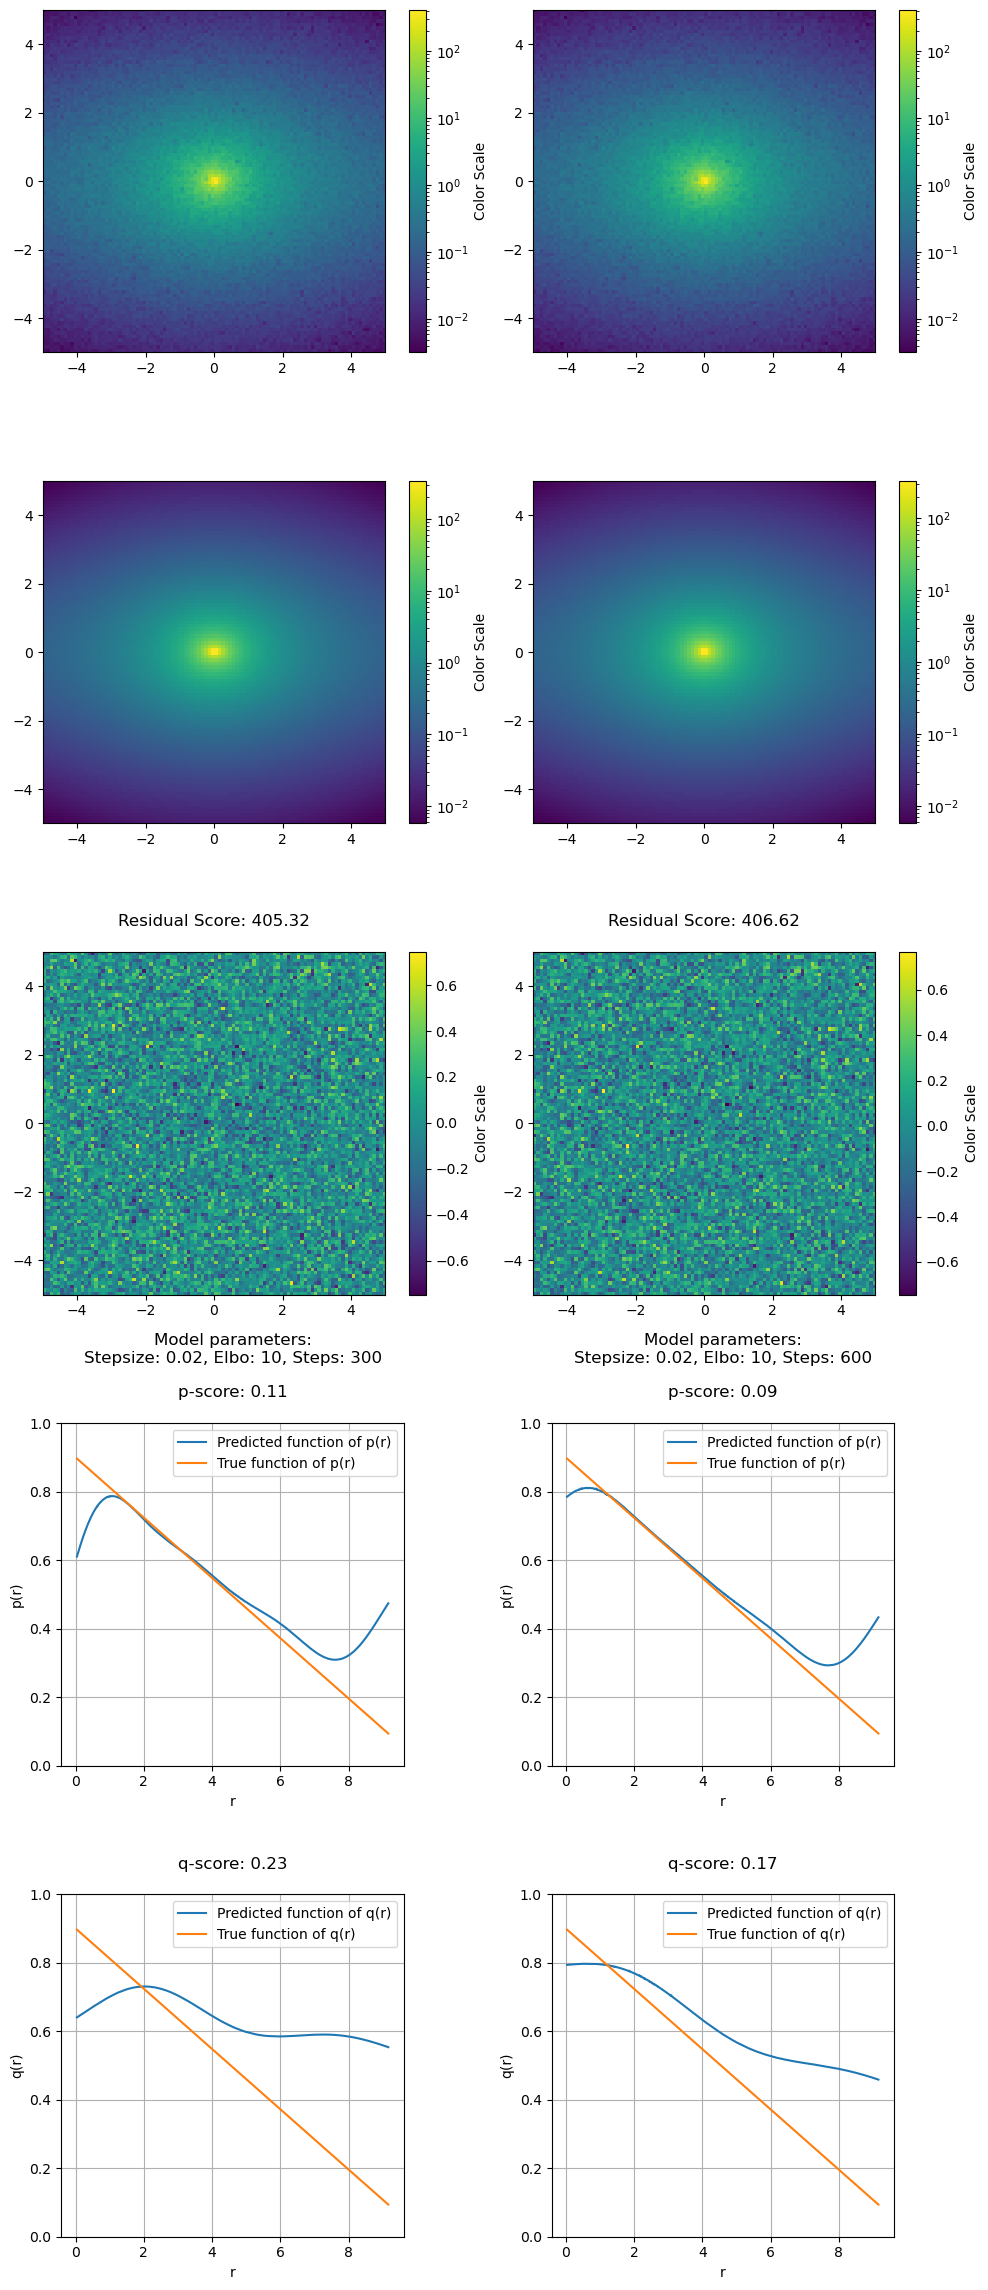

In [15]:
csv_results = []

adam_params = [0.02]
elbo_params = [10]
steps_param = [300,600]

input_data = [linear_decline_data] #[poly_extreme_data,poly_flat_data,const_low_data,const_high_data,linear_decline_data,linear_incline_data]
input_p = "linear_decline"
input_q = "linear_decline"

input_index = 4

model_name = "p(r)_q(r)"

fig, axes = plt.subplots(5,2, figsize=(10,23))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                q_mean = posterior_predictive_samples['q'].mean(axis=0)
                q_std = posterior_predictive_samples['q'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]

                p_obs = p(r_gp,p1,p2,p3,p4)
                q_obs = q(r_gp,p1,p2,p3,p4)

                p_score = float(score_r(p_obs,p_mean))
                q_score = float(score_r(q_obs,q_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score
                ph = None

                csv_entry = [model_name,input_p,input_q,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,q_score,ph,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]
                ax5 = axes[4,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                #ax1.set_title("True input: {} , {}".format(q_d_def,e_d_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                #ax2.set_title("Predicted values: {:.2f} , {:.2f}".format(q_pred,e_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

                ax5.plot(r_gp, q_mean, label="Predicted function of q(r)")
                ax5.plot(r_gp, q_obs, label="True function of q(r)")
                ax5.legend()
                ax5.set_xlabel('r')
                ax5.set_ylabel('q(r)')
                ax5.grid(True)
                ax5.set_ylim([0,1])
                ax5.set_title("q-score: {:.2f}\n".format(q_score))
                asp = np.diff(ax5.get_xlim())[0] / np.diff(ax5.get_ylim())[0]
                ax5.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + q(r) + e

0.02 10 300


100%|██████████| 300/300 [03:20<00:00,  1.50it/s, init loss: 46546.7734, avg. loss [286-300]: -31937.7061]


0.02 10 600


100%|██████████| 600/600 [06:33<00:00,  1.52it/s, init loss: 46546.7734, avg. loss [571-600]: -31971.7538]


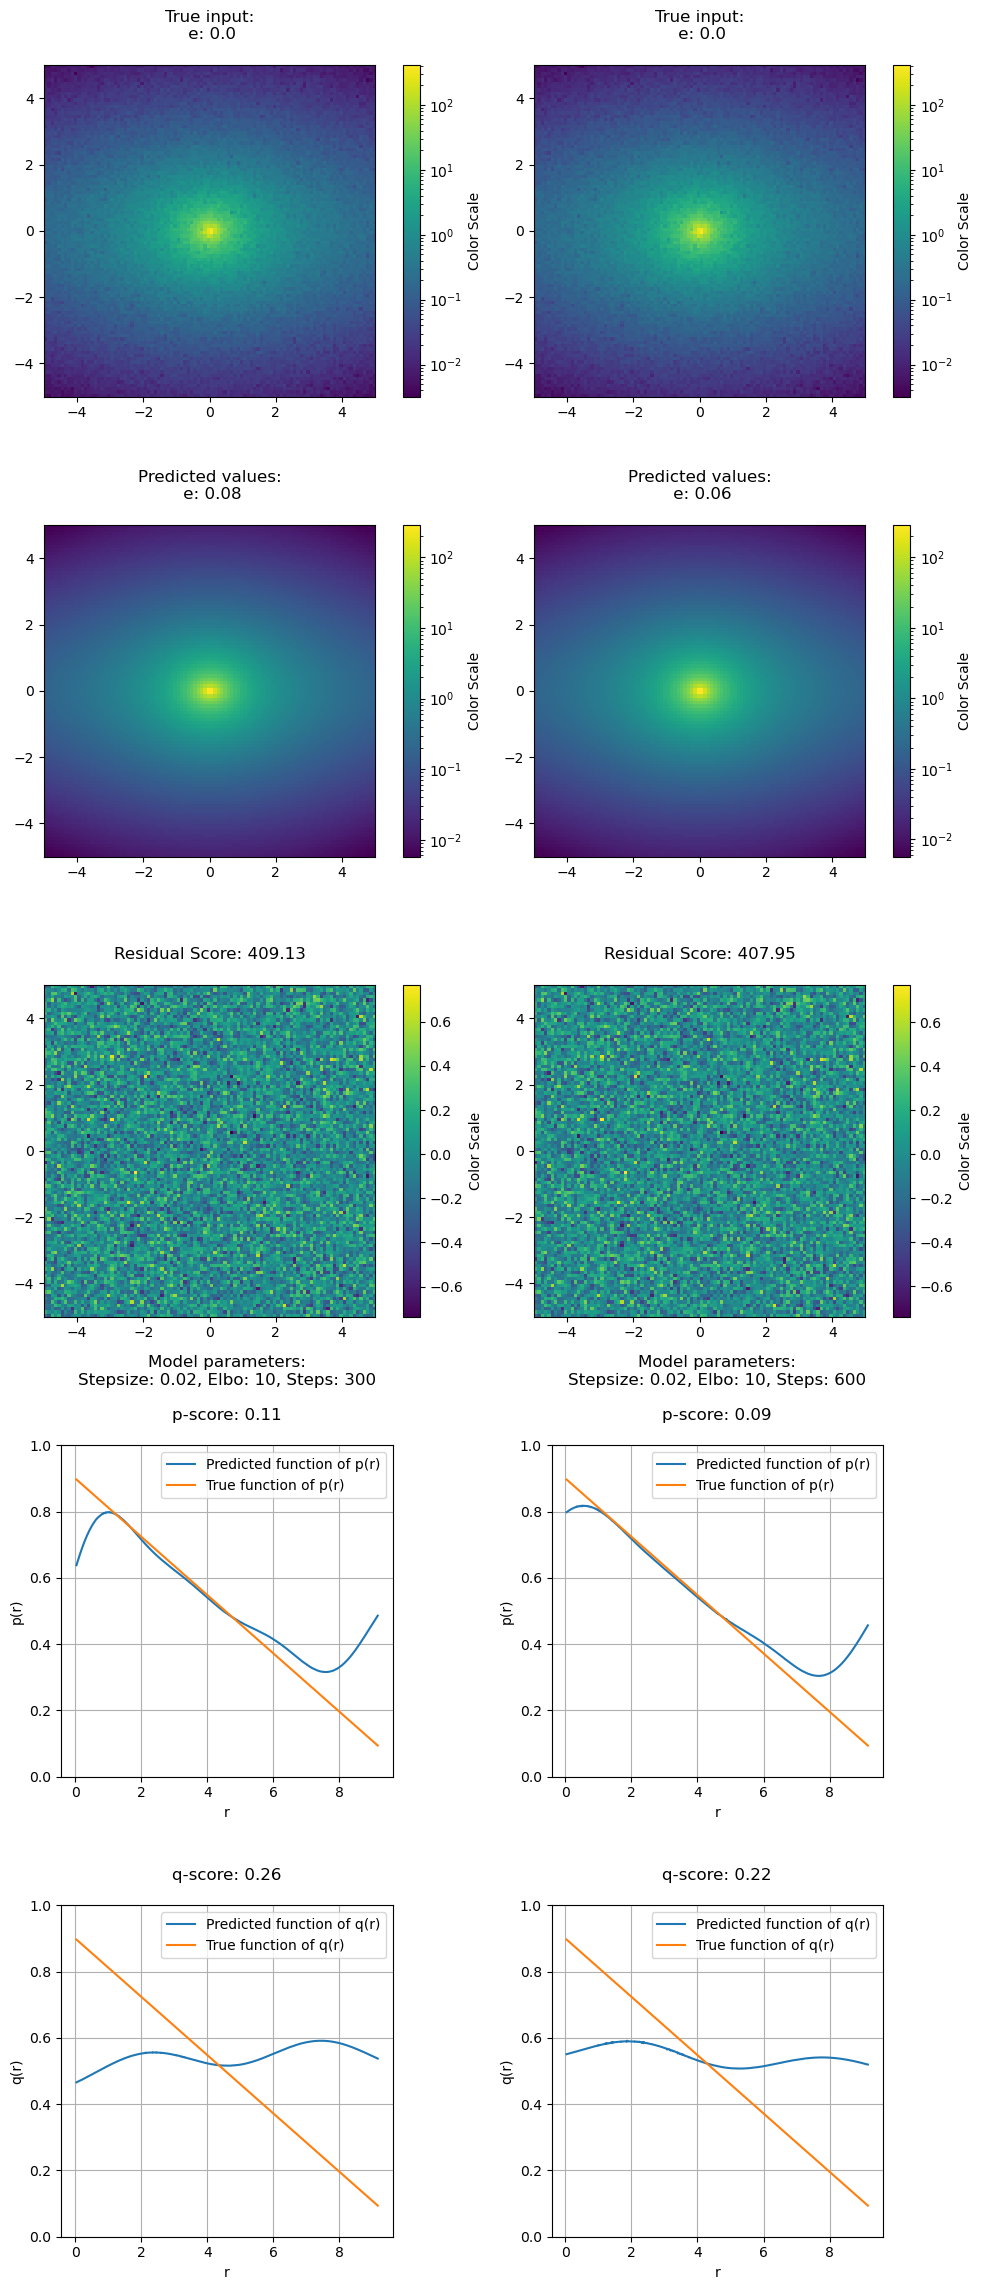

In [16]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    q0 = numpyro.sample('q0', dist.Uniform(0.001,1.)) # i.e. = q(0)
    q5 = numpyro.sample('q5', dist.Uniform(0.001,1.)) # i.e. = q(5)
    
    def linear_mean_function_q(r):
        return q0 + ((q5-q0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_q = numpyro.sample("sigma_q", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_q = numpyro.sample("length_scale_q", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    q_not_transformed = numpyro.sample("q_not_transformed", gp_q.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    q= numpyro.deterministic("q", jnp.clip(q_not_transformed+linear_mean_function_q(r_gp), min = 1e-10, max = 1.))
    interpolator_q = RegularGridInterpolator((r_gp,), q, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    q_final = interpolator_q(r)

    # Constant parameters
    e = numpyro.deterministic("e",numpyro.sample('e_sample', dist.Uniform(-1.,1.)))
    rho0 = 1.
    s = 1.0
    a = 2.0
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, 0.0, e, 0., 0., 0., p_final, 0., 0., 0., q_final, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)


model_name = "p(r)_q(r)_e"

fig, axes = plt.subplots(5,2, figsize=(10,23))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                e_pred = results.params['e_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                q_mean = posterior_predictive_samples['q'].mean(axis=0)
                q_std = posterior_predictive_samples['q'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]

                e_score = float(score_const(e_d_def,e_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
                q_obs = q(r_gp,p1,p2,p3,p4)

                p_score = float(score_r(p_obs,p_mean))
                q_score = float(score_r(q_obs,q_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score+e_score
                ph = None

                csv_entry = [model_name,input_p,input_q,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,e_d_def,e_pred,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,q_score,e_score,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]
                ax5 = axes[4,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n e: {}\n".format(e_d_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n e: {:.2f}\n".format(e_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

                ax5.plot(r_gp, q_mean, label="Predicted function of q(r)")
                ax5.plot(r_gp, q_obs, label="True function of q(r)")
                ax5.legend()
                ax5.set_xlabel('r')
                ax5.set_ylabel('q(r)')
                ax5.grid(True)
                ax5.set_ylim([0,1])
                ax5.set_title("q-score: {:.2f}\n".format(q_score))
                asp = np.diff(ax5.get_xlim())[0] / np.diff(ax5.get_ylim())[0]
                ax5.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + q(r) + e + rho0

0.02 10 300


100%|██████████| 300/300 [03:16<00:00,  1.53it/s, init loss: 200409.8125, avg. loss [286-300]: -31836.8082]


0.02 10 600


100%|██████████| 600/600 [06:22<00:00,  1.57it/s, init loss: 200409.8125, avg. loss [571-600]: -31887.6885]


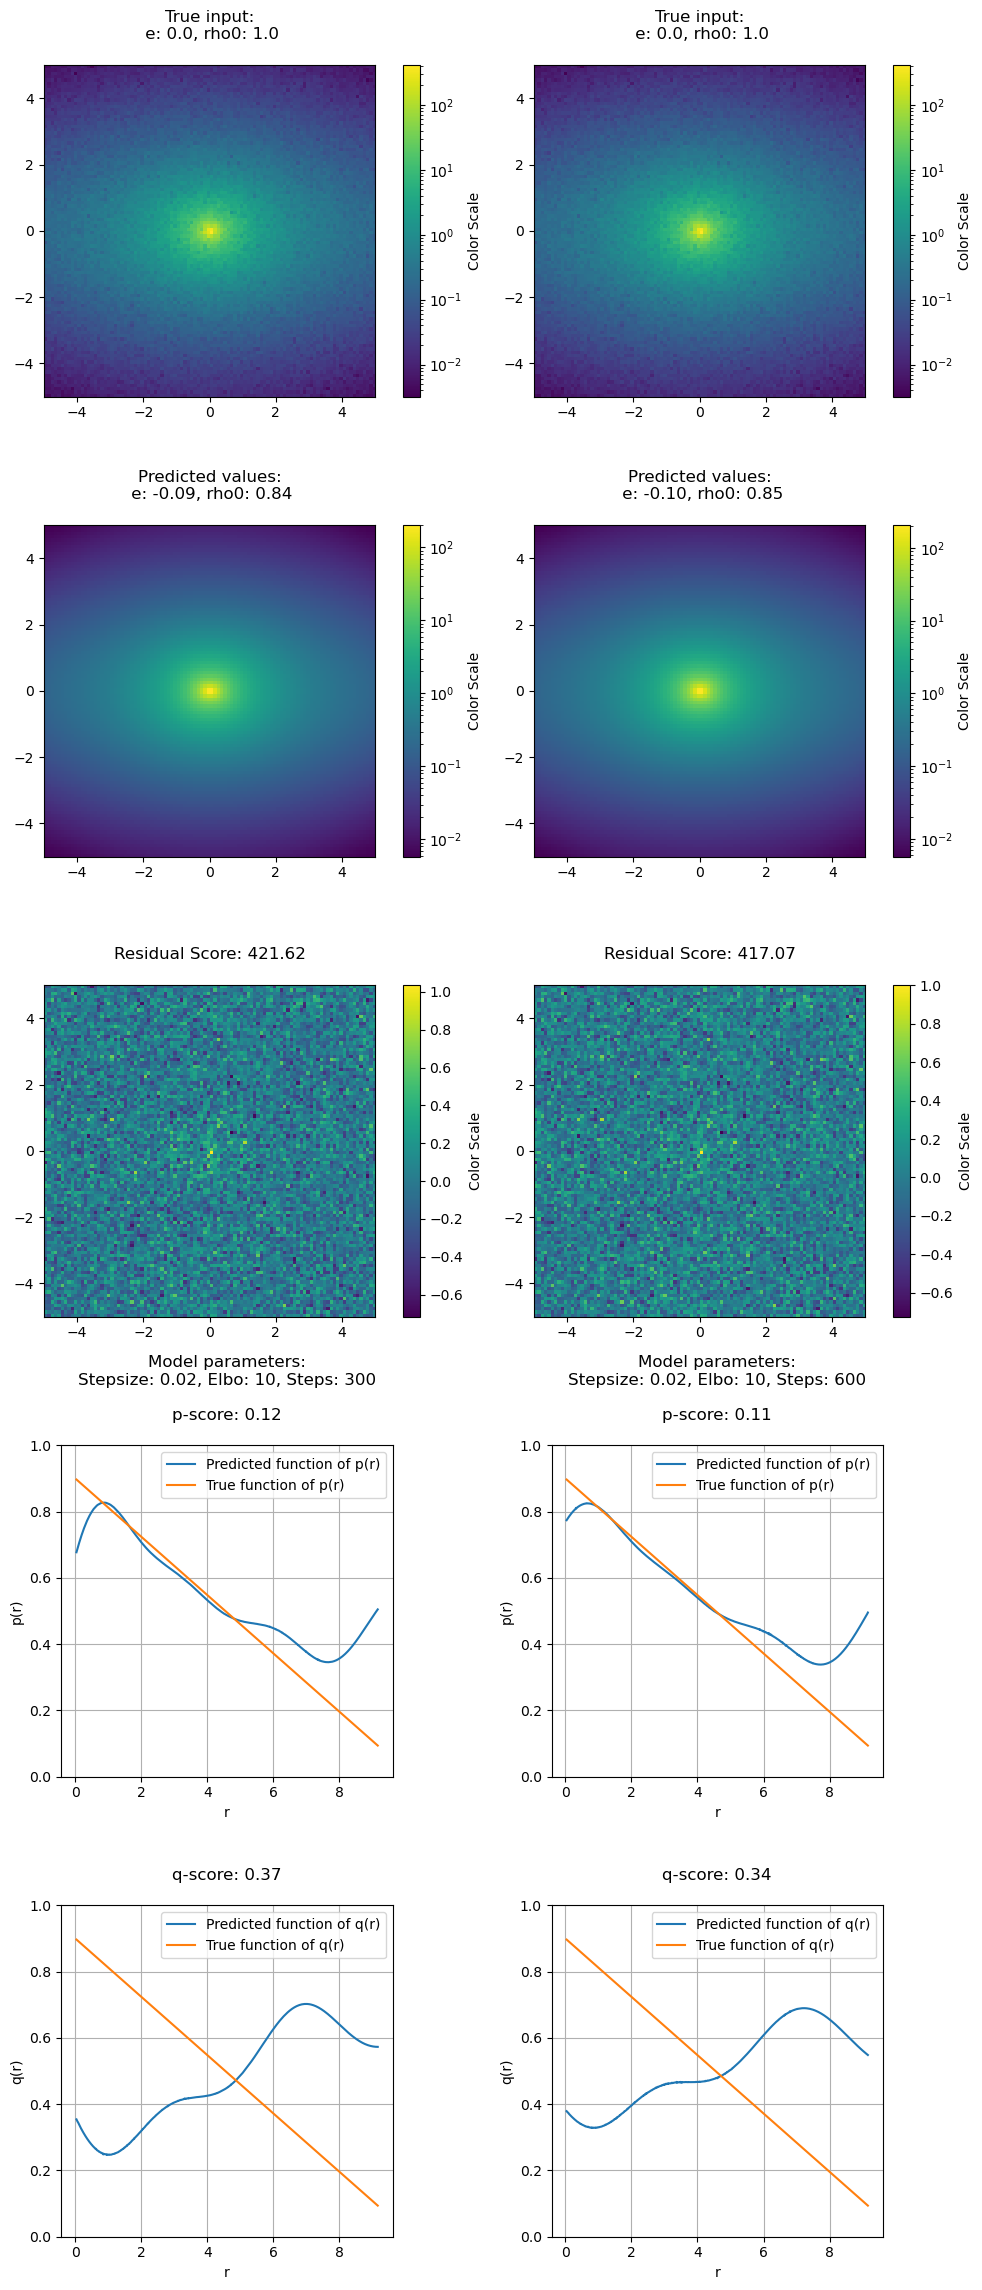

In [17]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    q0 = numpyro.sample('q0', dist.Uniform(0.001,1.)) # i.e. = q(0)
    q5 = numpyro.sample('q5', dist.Uniform(0.001,1.)) # i.e. = q(5)
    
    def linear_mean_function_q(r):
        return q0 + ((q5-q0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_q = numpyro.sample("sigma_q", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_q = numpyro.sample("length_scale_q", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    q_not_transformed = numpyro.sample("q_not_transformed", gp_q.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    q= numpyro.deterministic("q", jnp.clip(q_not_transformed+linear_mean_function_q(r_gp), min = 1e-10, max = 1.))
    interpolator_q = RegularGridInterpolator((r_gp,), q, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    q_final = interpolator_q(r)

    # Constant parameters
    e = numpyro.deterministic("e",numpyro.sample('e_sample', dist.Uniform(-1.,1.)))
    rho0 = numpyro.deterministic("rho0",numpyro.sample('rho0_sample', dist.Uniform(1e-10,1.)))
    s = 1.0
    a = 2.0
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, 0.0, e, 0., 0., 0., p_final, 0., 0., 0., q_final, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)


model_name = "p(r)_q(r)_e_rho0"

fig, axes = plt.subplots(5,2, figsize=(10,23))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                e_pred = results.params['e_sample_auto_loc']
                rho0_pred = results.params['rho0_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                q_mean = posterior_predictive_samples['q'].mean(axis=0)
                q_std = posterior_predictive_samples['q'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]

                e_score = float(score_const(e_d_def,e_pred))
                rho0_score = float(score_const(rho0_def,rho0_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
                q_obs = q(r_gp,p1,p2,p3,p4)

                p_score = float(score_r(p_obs,p_mean))
                q_score = float(score_r(q_obs,q_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score+e_score+rho0_score
                ph = None

                csv_entry = [model_name,input_p,input_q,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,e_d_def,e_pred,rho0_def,rho0_pred,rho0_score,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,q_score,e_score,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]
                ax5 = axes[4,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n e: {}, rho0: {}\n".format(e_d_def,rho0_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n e: {:.2f}, rho0: {:.2f}\n".format(e_pred,rho0_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

                ax5.plot(r_gp, q_mean, label="Predicted function of q(r)")
                ax5.plot(r_gp, q_obs, label="True function of q(r)")
                ax5.legend()
                ax5.set_xlabel('r')
                ax5.set_ylabel('q(r)')
                ax5.grid(True)
                ax5.set_ylim([0,1])
                ax5.set_title("q-score: {:.2f}\n".format(q_score))
                asp = np.diff(ax5.get_xlim())[0] / np.diff(ax5.get_ylim())[0]
                ax5.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + q(r) + e + rho0 + s

0.02 10 300


100%|██████████| 300/300 [03:14<00:00,  1.54it/s, init loss: 117473.2656, avg. loss [286-300]: -29586.8897]


0.02 10 600


100%|██████████| 600/600 [06:23<00:00,  1.57it/s, init loss: 117473.2656, avg. loss [571-600]: -31859.8554]


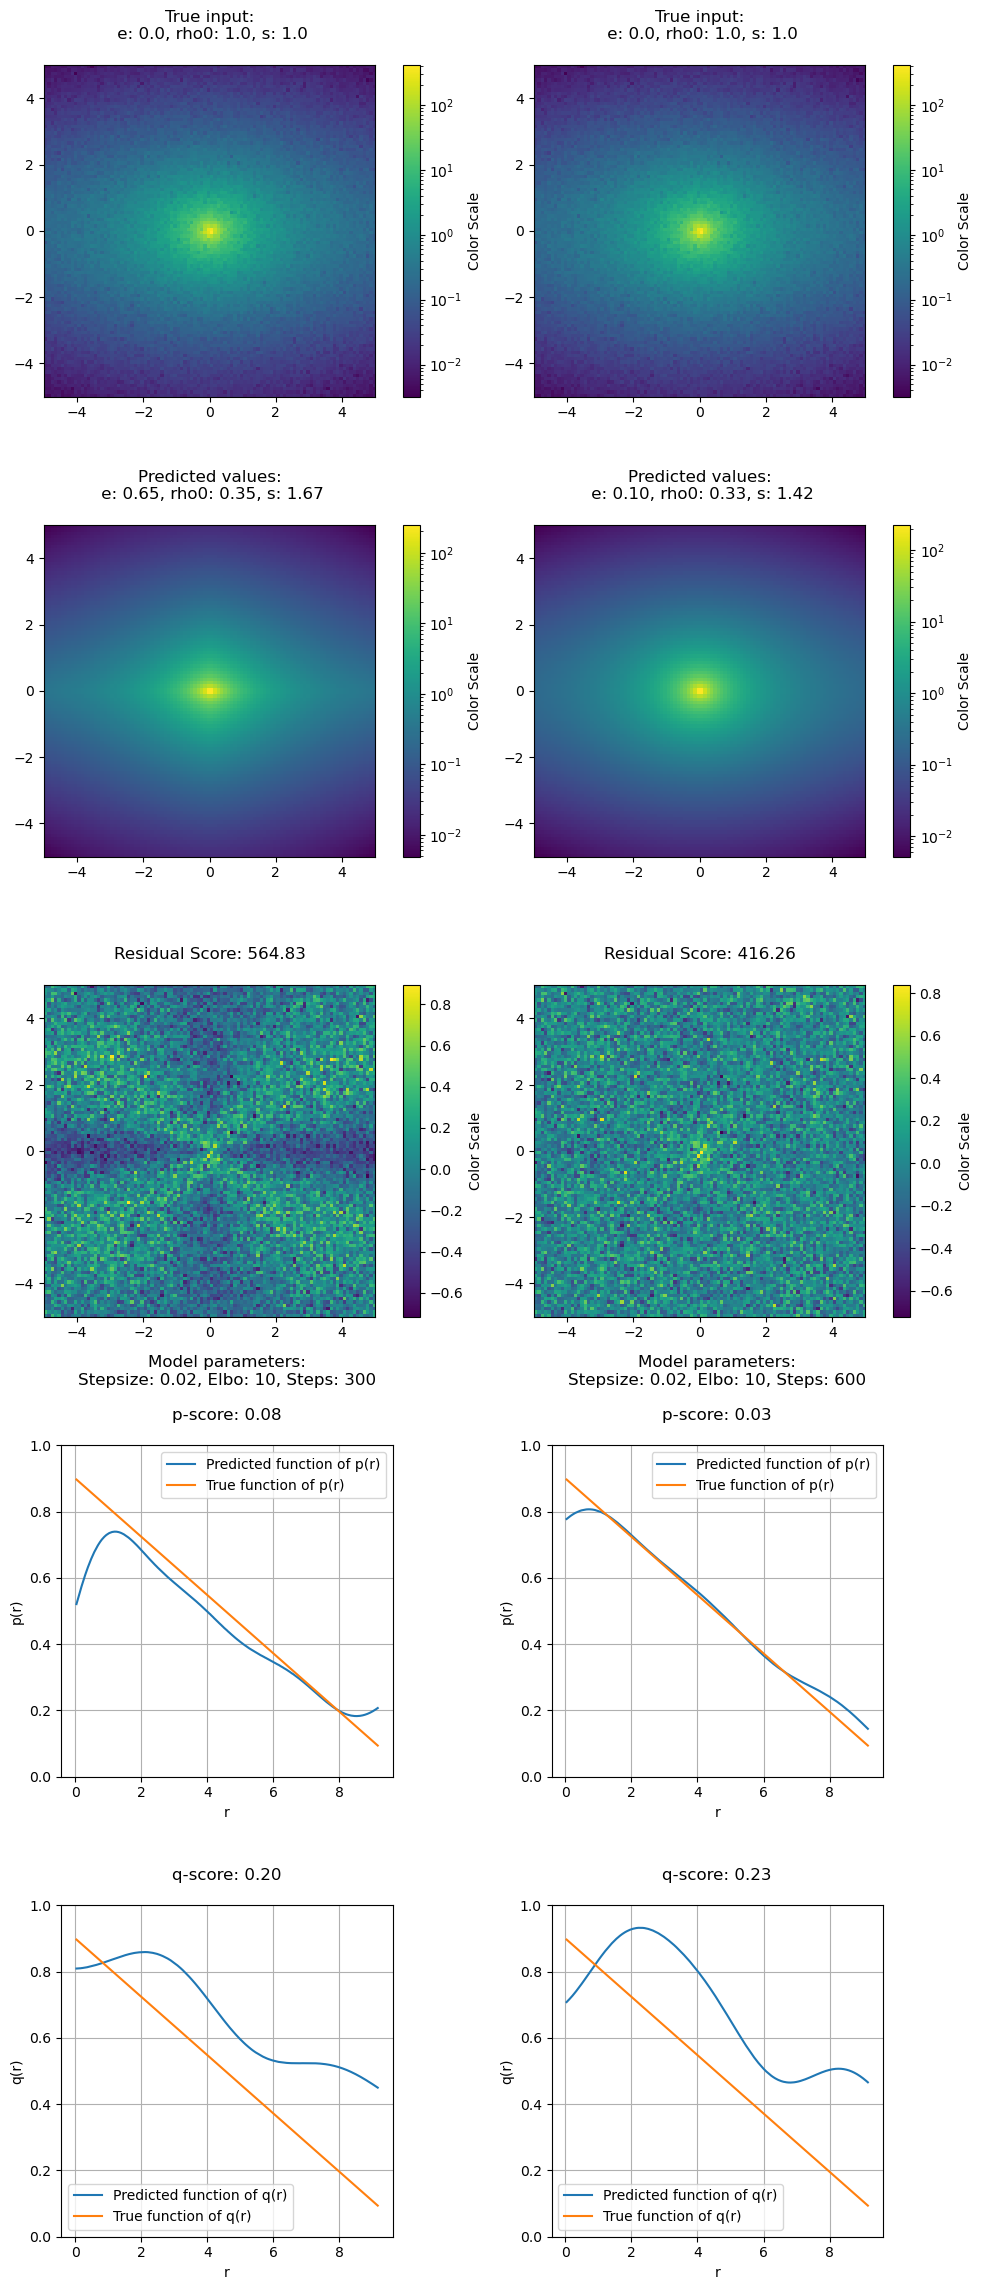

In [18]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    q0 = numpyro.sample('q0', dist.Uniform(0.001,1.)) # i.e. = q(0)
    q5 = numpyro.sample('q5', dist.Uniform(0.001,1.)) # i.e. = q(5)
    
    def linear_mean_function_q(r):
        return q0 + ((q5-q0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_q = numpyro.sample("sigma_q", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_q = numpyro.sample("length_scale_q", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    q_not_transformed = numpyro.sample("q_not_transformed", gp_q.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    q= numpyro.deterministic("q", jnp.clip(q_not_transformed+linear_mean_function_q(r_gp), min = 1e-10, max = 1.))
    interpolator_q = RegularGridInterpolator((r_gp,), q, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    q_final = interpolator_q(r)

    # Constant parameters
    e = numpyro.deterministic("e",numpyro.sample('e_sample', dist.Uniform(-1.,1.)))
    rho0 = numpyro.deterministic("rho0",numpyro.sample('rho0_sample', dist.Uniform(1e-10,1.)))
    s = numpyro.deterministic("s",numpyro.sample('s_sample', dist.Uniform(0.2,5.)))
    a = 2.0
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, 0.0, e, 0., 0., 0., p_final, 0., 0., 0., q_final, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)


model_name = "p(r)_q(r)_e_rho0_s"

fig, axes = plt.subplots(5,2, figsize=(10,23))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                
                e_pred = results.params['e_sample_auto_loc']
                rho0_pred = results.params['rho0_sample_auto_loc']
                s_pred = results.params['s_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                q_mean = posterior_predictive_samples['q'].mean(axis=0)
                q_std = posterior_predictive_samples['q'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]

                e_score = float(score_const(e_d_def,e_pred))
                rho0_score = float(score_const(rho0_def,rho0_pred))
                s_score = float(score_const(s_def,s_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
                q_obs = q(r_gp,p1,p2,p3,p4)

                p_score = float(score_r(p_obs,p_mean))
                q_score = float(score_r(q_obs,q_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score+e_score+rho0_score+s_score
                ph = None

                csv_entry = [model_name,input_p,input_q,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,e_d_def,e_pred,rho0_def,rho0_pred,rho0_score,s_def,s_pred,s_score,
                             ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,q_score,e_score,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]
                ax5 = axes[4,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n e: {}, rho0: {}, s: {}\n".format(e_d_def,rho0_def,s_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n e: {:.2f}, rho0: {:.2f}, s: {:.2f}\n".format(e_pred,rho0_pred,s_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

                ax5.plot(r_gp, q_mean, label="Predicted function of q(r)")
                ax5.plot(r_gp, q_obs, label="True function of q(r)")
                ax5.legend()
                ax5.set_xlabel('r')
                ax5.set_ylabel('q(r)')
                ax5.grid(True)
                ax5.set_ylim([0,1])
                ax5.set_title("q-score: {:.2f}\n".format(q_score))
                asp = np.diff(ax5.get_xlim())[0] / np.diff(ax5.get_ylim())[0]
                ax5.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + q(r) + e + rho0 + s + a

0.02 10 300


100%|██████████| 300/300 [03:26<00:00,  1.45it/s, init loss: 127768.7500, avg. loss [286-300]: -29348.9637]


0.02 10 600


100%|██████████| 600/600 [06:48<00:00,  1.47it/s, init loss: 127768.7500, avg. loss [571-600]: -31941.8715]


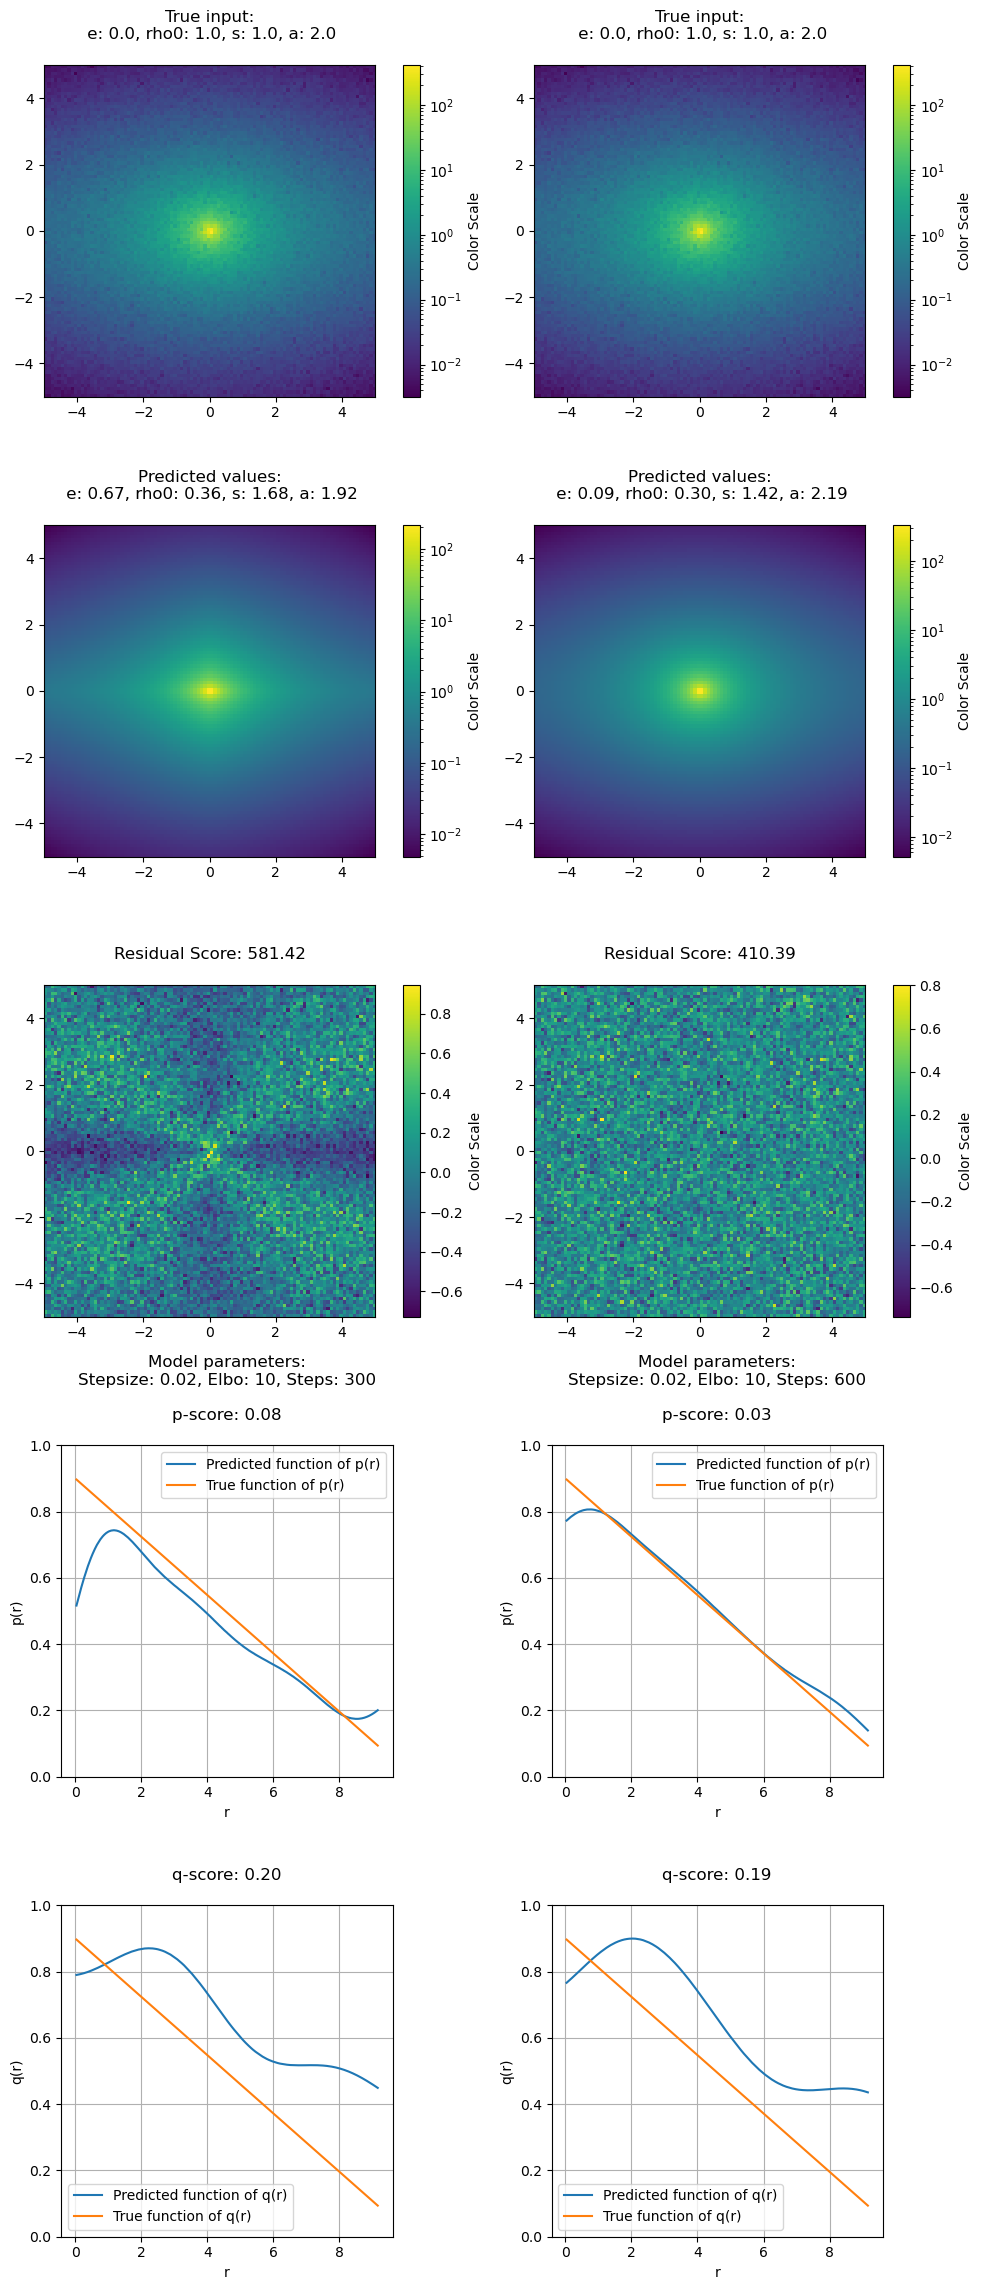

In [19]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    q0 = numpyro.sample('q0', dist.Uniform(0.001,1.)) # i.e. = q(0)
    q5 = numpyro.sample('q5', dist.Uniform(0.001,1.)) # i.e. = q(5)
    
    def linear_mean_function_q(r):
        return q0 + ((q5-q0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_q = numpyro.sample("sigma_q", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_q = numpyro.sample("length_scale_q", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    q_not_transformed = numpyro.sample("q_not_transformed", gp_q.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    q= numpyro.deterministic("q", jnp.clip(q_not_transformed+linear_mean_function_q(r_gp), min = 1e-10, max = 1.))
    interpolator_q = RegularGridInterpolator((r_gp,), q, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    q_final = interpolator_q(r)

    # Constant parameters
    e = numpyro.deterministic("e",numpyro.sample('e_sample', dist.Uniform(-1.,1.)))
    rho0 = numpyro.deterministic("rho0",numpyro.sample('rho0_sample', dist.Uniform(1e-10,1.)))
    s = numpyro.deterministic("s",numpyro.sample('s_sample', dist.Uniform(0.2,5.)))
    a = numpyro.deterministic("a",numpyro.sample('a_sample', dist.Uniform(1.,5.)))
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, 0.0, e, 0., 0., 0., p_final, 0., 0., 0., q_final, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_q(r)_e_rho0_s_a"

fig, axes = plt.subplots(5,2, figsize=(10,23))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                
                e_pred = results.params['e_sample_auto_loc']
                rho0_pred = results.params['rho0_sample_auto_loc']
                s_pred = results.params['s_sample_auto_loc']
                a_pred = results.params['a_sample_auto_loc']
                
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                q_mean = posterior_predictive_samples['q'].mean(axis=0)
                q_std = posterior_predictive_samples['q'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]

                e_score = float(score_const(e_d_def,e_pred))
                rho0_score = float(score_const(rho0_def,rho0_pred))
                s_score = float(score_const(s_def,s_pred))
                a_score = float(score_const(a_def,a_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
                q_obs = q(r_gp,p1,p2,p3,p4)

                p_score = float(score_r(p_obs,p_mean))
                q_score = float(score_r(q_obs,q_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score+e_score+rho0_score+s_score+a_score
                ph = None

                csv_entry = [model_name,input_p,input_q,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,e_d_def,e_pred,rho0_def,rho0_pred,rho0_score,s_def,s_pred,s_score,
                             a_def,a_pred,a_score,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,q_score,e_score,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]
                ax5 = axes[4,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n e: {}, rho0: {}, s: {}, a: {}\n".format(e_d_def,rho0_def,s_def,a_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n e: {:.2f}, rho0: {:.2f}, s: {:.2f}, a: {:.2f}\n".format(e_pred,rho0_pred,s_pred,a_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

                ax5.plot(r_gp, q_mean, label="Predicted function of q(r)")
                ax5.plot(r_gp, q_obs, label="True function of q(r)")
                ax5.legend()
                ax5.set_xlabel('r')
                ax5.set_ylabel('q(r)')
                ax5.grid(True)
                ax5.set_ylim([0,1])
                ax5.set_title("q-score: {:.2f}\n".format(q_score))
                asp = np.diff(ax5.get_xlim())[0] / np.diff(ax5.get_ylim())[0]
                ax5.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + q(r) + e + rho0 + s + a + b

0.02 10 300


100%|██████████| 300/300 [03:33<00:00,  1.41it/s, init loss: 142822.1250, avg. loss [286-300]: -28693.8527]


0.02 10 600


100%|██████████| 600/600 [06:54<00:00,  1.45it/s, init loss: 142822.1250, avg. loss [571-600]: -31934.3265]


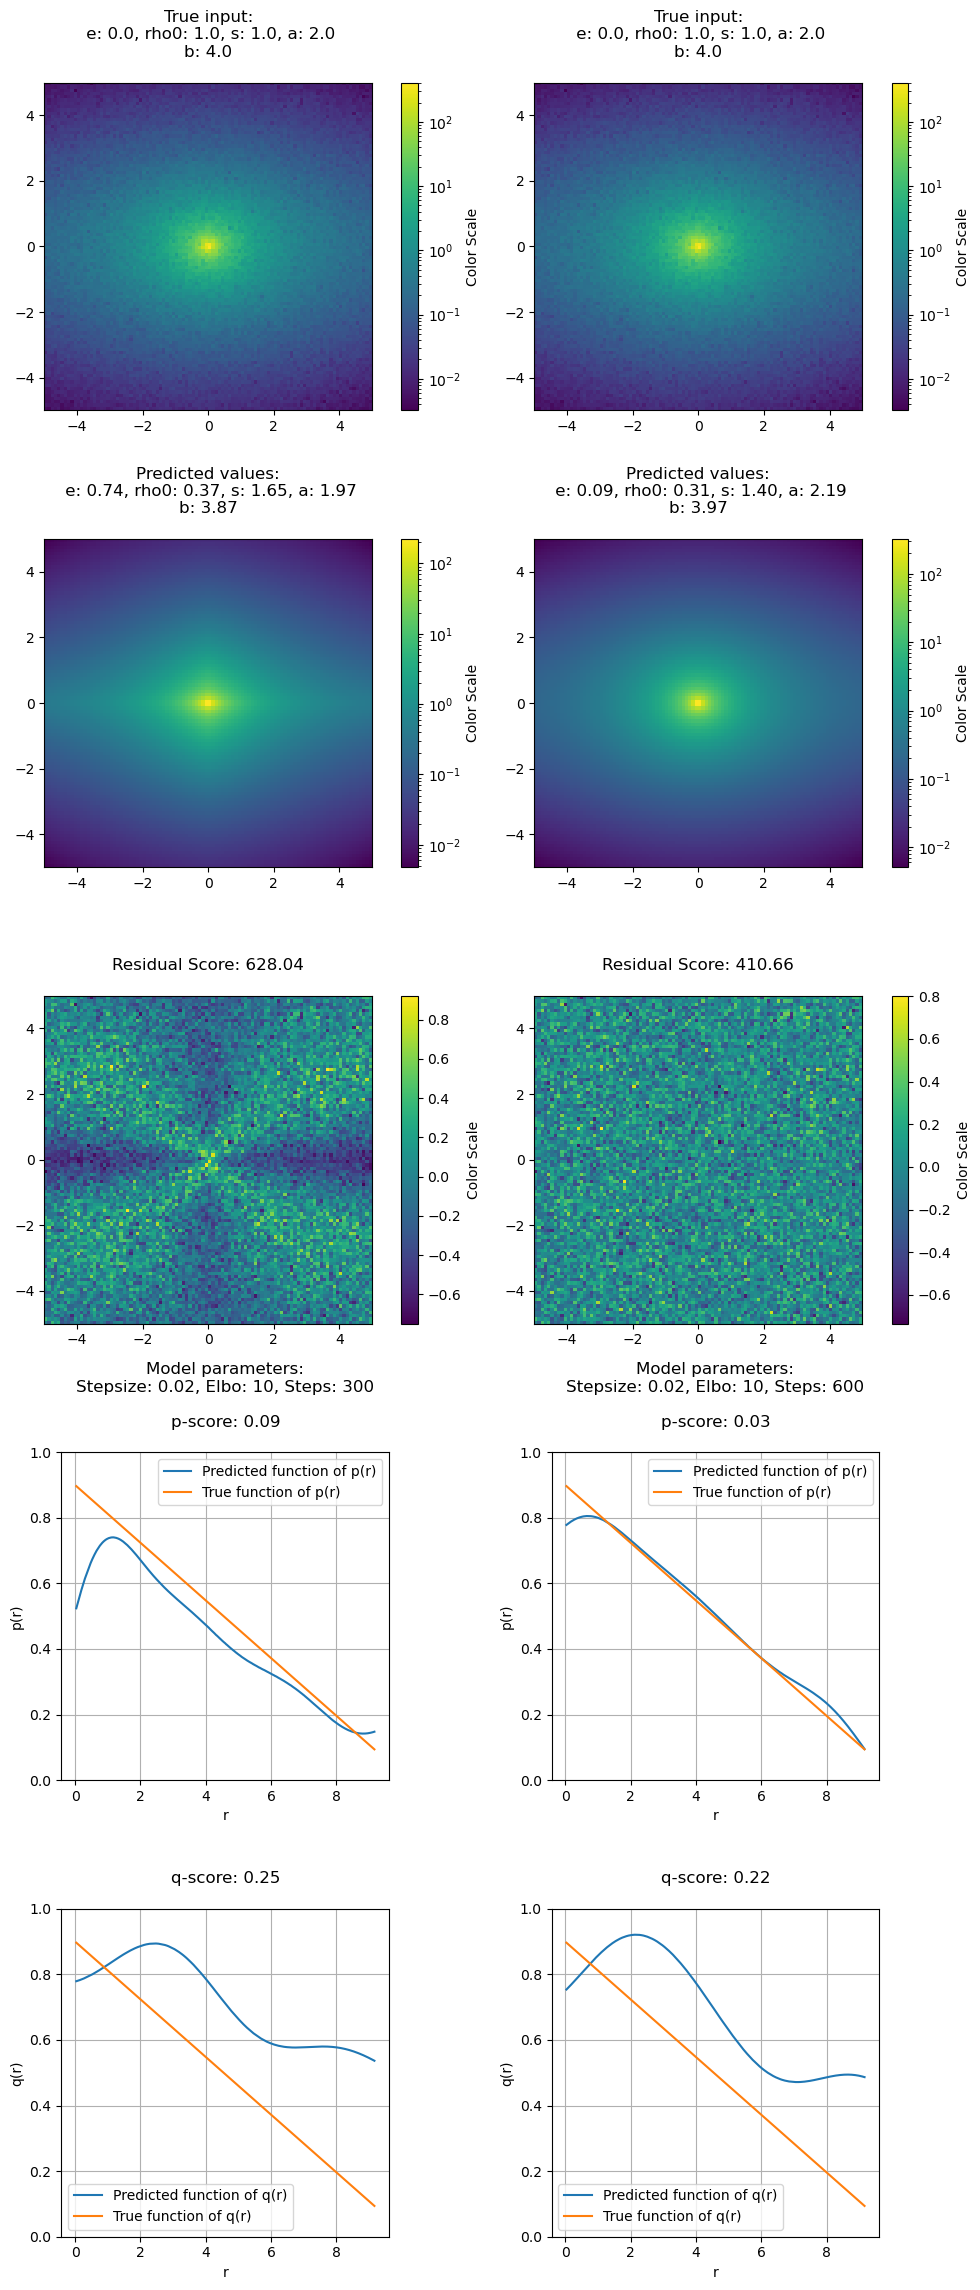

In [20]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    q0 = numpyro.sample('q0', dist.Uniform(0.001,1.)) # i.e. = q(0)
    q5 = numpyro.sample('q5', dist.Uniform(0.001,1.)) # i.e. = q(5)
    
    def linear_mean_function_q(r):
        return q0 + ((q5-q0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_q = numpyro.sample("sigma_q", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_q = numpyro.sample("length_scale_q", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    q_not_transformed = numpyro.sample("q_not_transformed", gp_q.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    q= numpyro.deterministic("q", jnp.clip(q_not_transformed+linear_mean_function_q(r_gp), min = 1e-10, max = 1.))
    interpolator_q = RegularGridInterpolator((r_gp,), q, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    q_final = interpolator_q(r)

    # Constant parameters
    e = numpyro.deterministic("e",numpyro.sample('e_sample', dist.Uniform(-1.,1.)))
    rho0 = numpyro.deterministic("rho0",numpyro.sample('rho0_sample', dist.Uniform(1e-10,1.)))
    s = numpyro.deterministic("s",numpyro.sample('s_sample', dist.Uniform(0.2,5.)))
    a = numpyro.deterministic("a",numpyro.sample('a_sample', dist.Uniform(1.,5.)))
    b = numpyro.deterministic("b",numpyro.sample('b_sample', dist.Uniform(1.0,5.0)))
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, 0.0, e, 0., 0., 0., p_final, 0., 0., 0., q_final, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_q(r)_e_rho0_s_a_b"

fig, axes = plt.subplots(5,2, figsize=(10,23))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                e_pred = results.params['e_sample_auto_loc']
                rho0_pred = results.params['rho0_sample_auto_loc']
                s_pred = results.params['s_sample_auto_loc']
                a_pred = results.params['a_sample_auto_loc']
                b_pred = results.params['b_sample_auto_loc']
                
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                q_mean = posterior_predictive_samples['q'].mean(axis=0)
                q_std = posterior_predictive_samples['q'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]

                e_score = float(score_const(e_d_def,e_pred))
                rho0_score = float(score_const(rho0_def,rho0_pred))
                s_score = float(score_const(s_def,s_pred))
                a_score = float(score_const(a_def,a_pred))
                b_score = float(score_const(b_def,b_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
                q_obs = q(r_gp,p1,p2,p3,p4)

                p_score = float(score_r(p_obs,p_mean))
                q_score = float(score_r(q_obs,q_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score+e_score+rho0_score+s_score+a_score+b_score
                ph = None

                csv_entry = [model_name,input_p,input_q,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,e_d_def,e_pred,rho0_def,rho0_pred,rho0_score,s_def,s_pred,s_score,
                             a_def,a_pred,a_score,b_def,b_pred,b_score,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,q_score,e_score,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]
                ax5 = axes[4,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n e: {}, rho0: {}, s: {}, a: {}\nb: {}\n".format(e_d_def,rho0_def,s_def,a_def,b_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n e: {:.2f}, rho0: {:.2f}, s: {:.2f}, a: {:.2f}\nb: {:.2f}\n".format(e_pred,rho0_pred,s_pred,a_pred,b_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

                ax5.plot(r_gp, q_mean, label="Predicted function of q(r)")
                ax5.plot(r_gp, q_obs, label="True function of q(r)")
                ax5.legend()
                ax5.set_xlabel('r')
                ax5.set_ylabel('q(r)')
                ax5.grid(True)
                ax5.set_ylim([0,1])
                ax5.set_title("q-score: {:.2f}\n".format(q_score))
                asp = np.diff(ax5.get_xlim())[0] / np.diff(ax5.get_ylim())[0]
                ax5.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + q(r) + e + rho0 + s + a + b + i

0.02 10 300


100%|██████████| 300/300 [04:07<00:00,  1.21it/s, init loss: 145301.0156, avg. loss [286-300]: -30571.5234]


0.02 10 600


100%|██████████| 600/600 [08:08<00:00,  1.23it/s, init loss: 145301.0156, avg. loss [571-600]: -31773.7374]


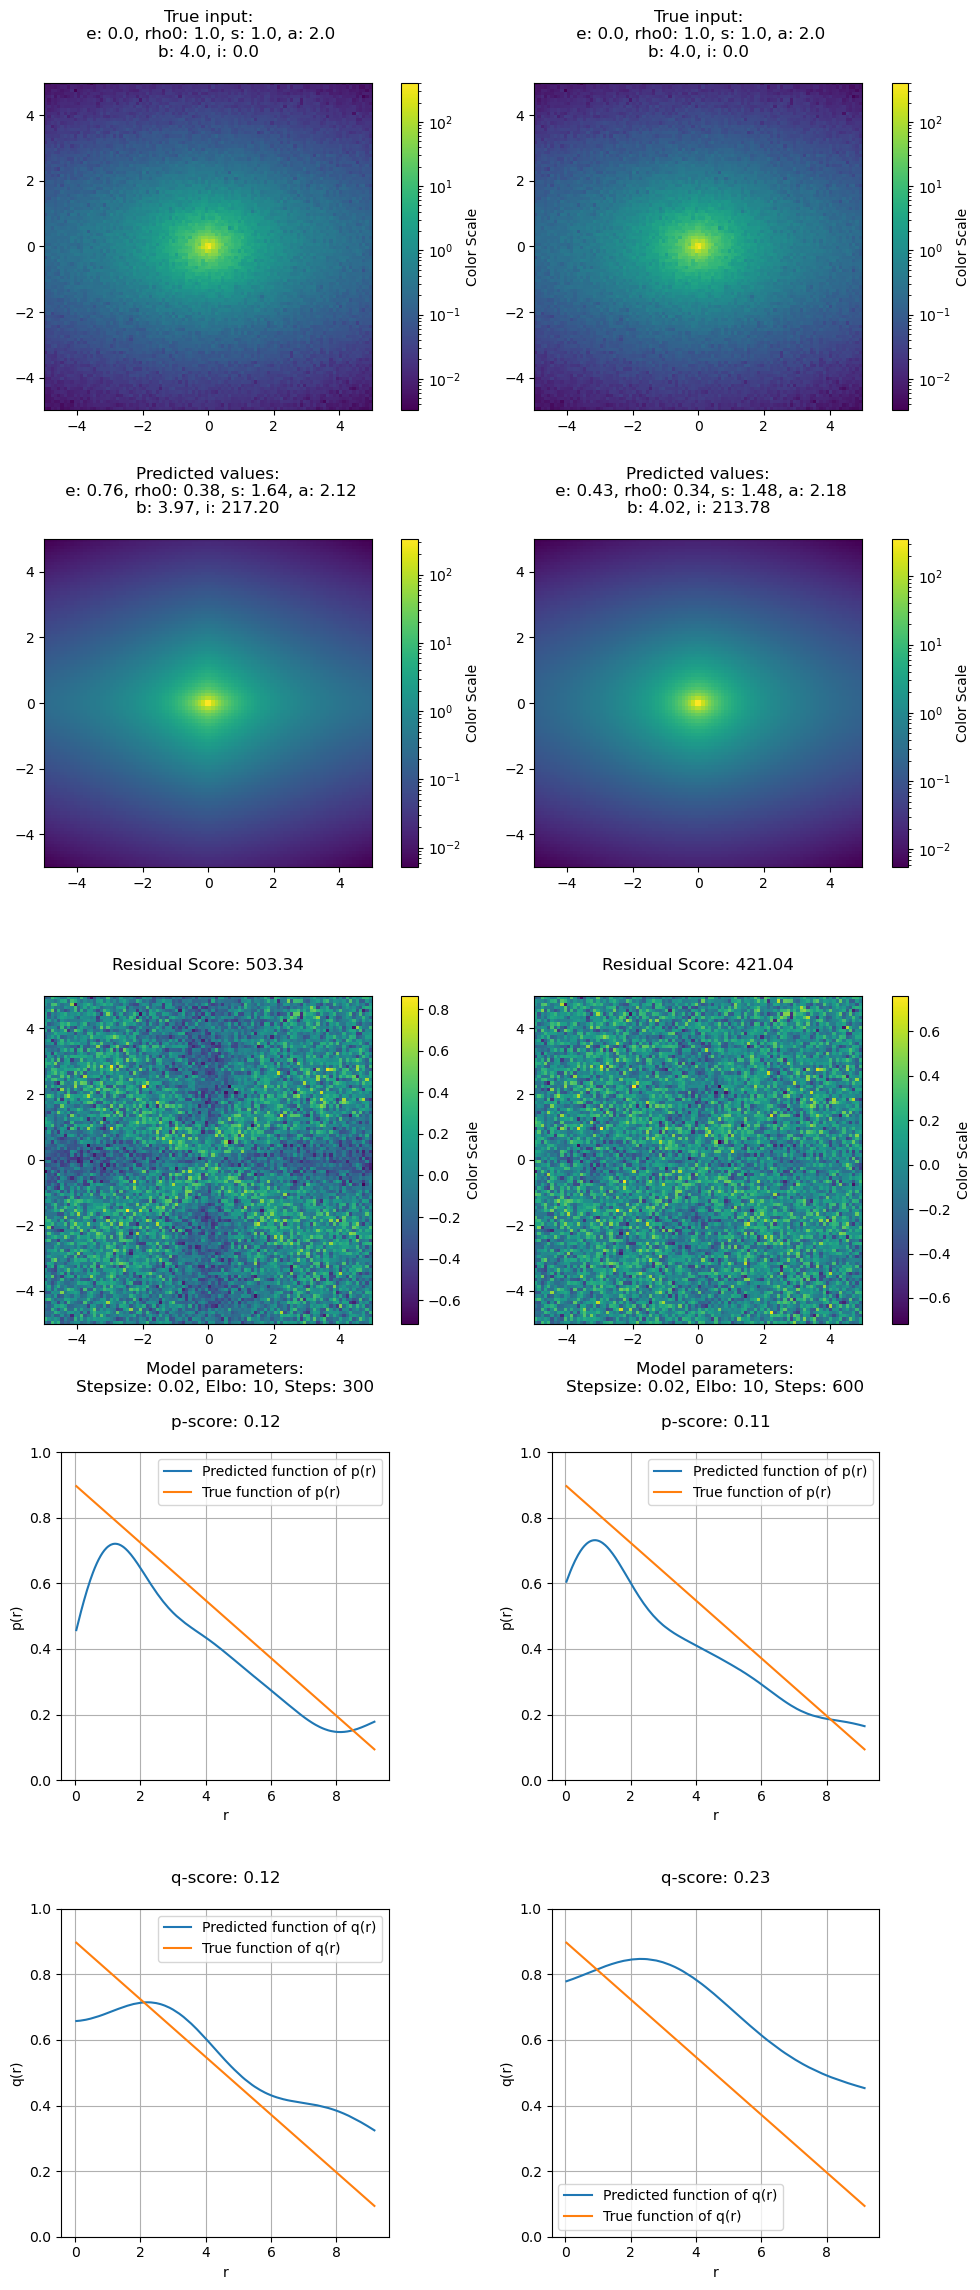

In [21]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    q0 = numpyro.sample('q0', dist.Uniform(0.001,1.)) # i.e. = q(0)
    q5 = numpyro.sample('q5', dist.Uniform(0.001,1.)) # i.e. = q(5)
    
    def linear_mean_function_q(r):
        return q0 + ((q5-q0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_q = numpyro.sample("sigma_q", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_q = numpyro.sample("length_scale_q", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    q_not_transformed = numpyro.sample("q_not_transformed", gp_q.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    q= numpyro.deterministic("q", jnp.clip(q_not_transformed+linear_mean_function_q(r_gp), min = 1e-10, max = 1.))
    interpolator_q = RegularGridInterpolator((r_gp,), q, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    q_final = interpolator_q(r)

    # Constant parameters
    e = numpyro.deterministic("e",numpyro.sample('e_sample', dist.Uniform(-1.,1.)))
    rho0 = numpyro.deterministic("rho0",numpyro.sample('rho0_sample', dist.Uniform(1e-10,1.)))
    s = numpyro.deterministic("s",numpyro.sample('s_sample', dist.Uniform(0.2,5.)))
    a = numpyro.deterministic("a",numpyro.sample('a_sample', dist.Uniform(1.,5.)))
    b = numpyro.deterministic("b",numpyro.sample('b_sample', dist.Uniform(1.0,5.0)))
    i = numpyro.deterministic("i",numpyro.sample('i_sample', dist.Uniform(0.,360.)))
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, 0.0, e, 0., 0., 0., p_final, 0., 0., 0., q_final, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_q(r)_e_rho0_s_a_b_i"

fig, axes = plt.subplots(5,2, figsize=(10,23))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                e_pred = results.params['e_sample_auto_loc']
                rho0_pred = results.params['rho0_sample_auto_loc']
                s_pred = results.params['s_sample_auto_loc']
                a_pred = results.params['a_sample_auto_loc']
                b_pred = results.params['b_sample_auto_loc']
                i_pred = results.params['i_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                q_mean = posterior_predictive_samples['q'].mean(axis=0)
                q_std = posterior_predictive_samples['q'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]

                e_score = float(score_const(e_d_def,e_pred))
                rho0_score = float(score_const(rho0_def,rho0_pred))
                s_score = float(score_const(s_def,s_pred))
                a_score = float(score_const(a_def,a_pred))
                b_score = float(score_const(b_def,b_pred))
                i_score = float(score_const(i_def,i_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
                q_obs = q(r_gp,p1,p2,p3,p4)

                p_score = float(score_r(p_obs,p_mean))
                q_score = float(score_r(q_obs,q_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score+e_score+rho0_score+s_score+a_score+b_score+i_score
                ph = None

                csv_entry = [model_name,input_p,input_q,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,e_d_def,e_pred,rho0_def,rho0_pred,rho0_score,s_def,s_pred,s_score,
                             a_def,a_pred,a_score,b_def,b_pred,b_score,i_def,i_pred,i_score,ph,ph,ph,ph,ph,ph,p_score,q_score,e_score,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]
                ax5 = axes[4,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n e: {}, rho0: {}, s: {}, a: {}\nb: {}, i: {}\n".format(e_d_def,rho0_def,s_def,a_def,b_def,i_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n e: {:.2f}, rho0: {:.2f}, s: {:.2f}, a: {:.2f}\nb: {:.2f}, i: {:.2f}\n".format(e_pred,rho0_pred,s_pred,a_pred,b_pred,i_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

                ax5.plot(r_gp, q_mean, label="Predicted function of q(r)")
                ax5.plot(r_gp, q_obs, label="True function of q(r)")
                ax5.legend()
                ax5.set_xlabel('r')
                ax5.set_ylabel('q(r)')
                ax5.grid(True)
                ax5.set_ylim([0,1])
                ax5.set_title("q-score: {:.2f}\n".format(q_score))
                asp = np.diff(ax5.get_xlim())[0] / np.diff(ax5.get_ylim())[0]
                ax5.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + q(r) + e + rho0 + s + a + b + i +phi

0.02 10 300


100%|██████████| 300/300 [04:09<00:00,  1.20it/s, init loss: 145400.0156, avg. loss [286-300]: -30526.4987]


0.02 10 600


100%|██████████| 600/600 [08:14<00:00,  1.21it/s, init loss: 145400.0156, avg. loss [571-600]: -31983.6167]


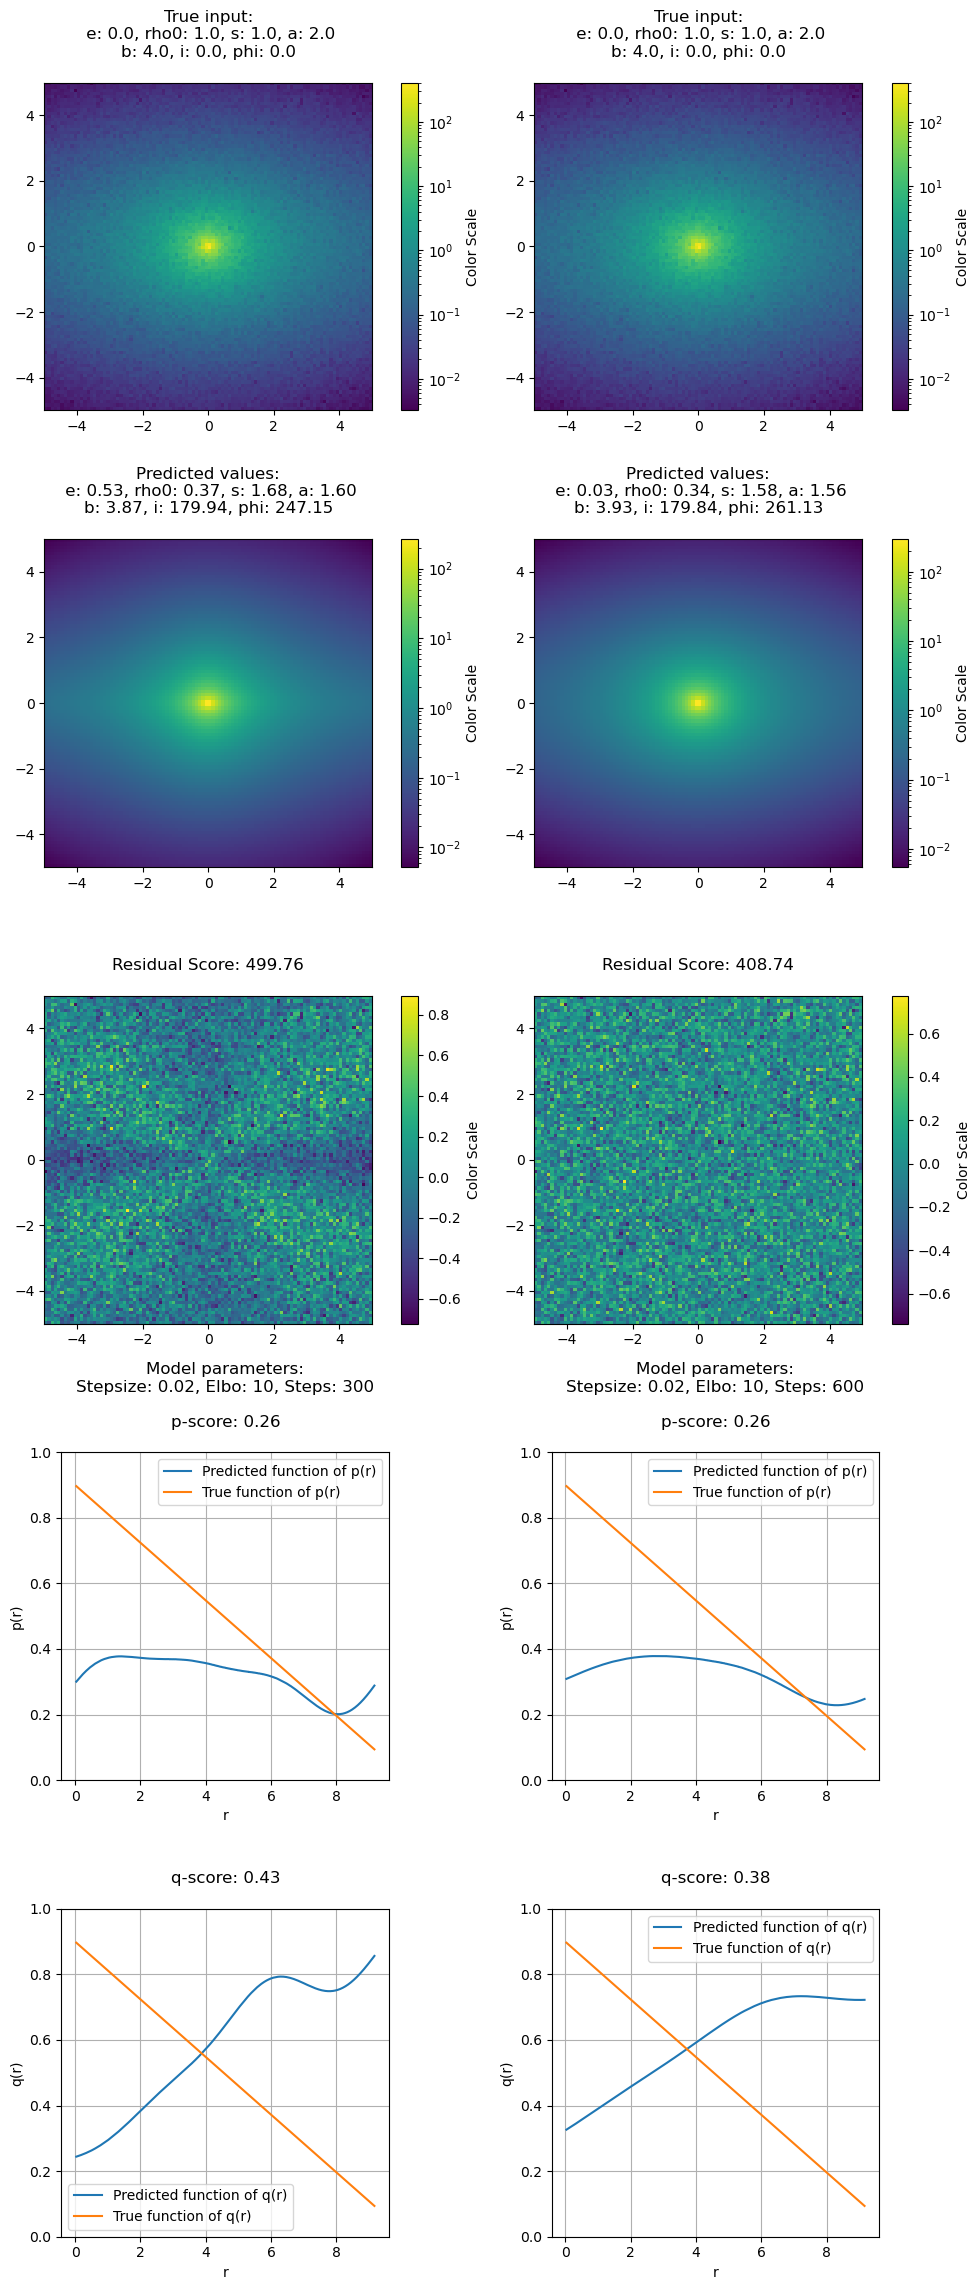

In [22]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    q0 = numpyro.sample('q0', dist.Uniform(0.001,1.)) # i.e. = q(0)
    q5 = numpyro.sample('q5', dist.Uniform(0.001,1.)) # i.e. = q(5)
    
    def linear_mean_function_q(r):
        return q0 + ((q5-q0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_q = numpyro.sample("sigma_q", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_q = numpyro.sample("length_scale_q", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    q_not_transformed = numpyro.sample("q_not_transformed", gp_q.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    q= numpyro.deterministic("q", jnp.clip(q_not_transformed+linear_mean_function_q(r_gp), min = 1e-10, max = 1.))
    interpolator_q = RegularGridInterpolator((r_gp,), q, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    q_final = interpolator_q(r)

    # Constant parameters
    e = numpyro.deterministic("e",numpyro.sample('e_sample', dist.Uniform(-1.,1.)))
    rho0 = numpyro.deterministic("rho0",numpyro.sample('rho0_sample', dist.Uniform(1e-10,1.)))
    s = numpyro.deterministic("s",numpyro.sample('s_sample', dist.Uniform(0.2,5.)))
    a = numpyro.deterministic("a",numpyro.sample('a_sample', dist.Uniform(1.,5.)))
    b = numpyro.deterministic("b",numpyro.sample('b_sample', dist.Uniform(1.0,5.0)))
    i = numpyro.deterministic("i",numpyro.sample('i_sample', dist.Uniform(0.,360.)))
    phi = numpyro.deterministic("phi",numpyro.sample('phi_sample', dist.Uniform(0.,360.)))
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, 0.0, e, 0., 0., 0., p_final, 0., 0., 0., q_final, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_q(r)_e_rho0_s_a_b_i_phi"

fig, axes = plt.subplots(5,2, figsize=(10,23))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                e_pred = results.params['e_sample_auto_loc']
                rho0_pred = results.params['rho0_sample_auto_loc']
                s_pred = results.params['s_sample_auto_loc']
                a_pred = results.params['a_sample_auto_loc']
                b_pred = results.params['b_sample_auto_loc']
                i_pred = results.params['i_sample_auto_loc']
                phi_pred = results.params['phi_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                q_mean = posterior_predictive_samples['q'].mean(axis=0)
                q_std = posterior_predictive_samples['q'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]

                e_score = float(score_const(e_d_def,e_pred))
                rho0_score = float(score_const(rho0_def,rho0_pred))
                s_score = float(score_const(s_def,s_pred))
                a_score = float(score_const(a_def,a_pred))
                b_score = float(score_const(b_def,b_pred))
                i_score = float(score_const(i_def,i_pred))
                phi_score = float(score_const(phi_def,phi_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
                q_obs = q(r_gp,p1,p2,p3,p4)

                p_score = float(score_r(p_obs,p_mean))
                q_score = float(score_r(q_obs,q_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score+e_score+rho0_score+s_score+a_score+b_score+i_score+phi_score
                ph = None

                csv_entry = [model_name,input_p,input_q,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,e_d_def,e_pred,rho0_def,rho0_pred,rho0_score,s_def,s_pred,s_score,
                             a_def,a_pred,a_score,b_def,b_pred,b_score,i_def,i_pred,i_score,phi_def,phi_pred,phi_score,ph,ph,ph,p_score,q_score,e_score,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]
                ax5 = axes[4,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n e: {}, rho0: {}, s: {}, a: {}\nb: {}, i: {}, phi: {}\n".format(e_d_def,rho0_def,s_def,a_def,b_def,i_def,phi_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n e: {:.2f}, rho0: {:.2f}, s: {:.2f}, a: {:.2f}\nb: {:.2f}, i: {:.2f}, phi: {:.2f}\n".format(e_pred,rho0_pred,s_pred,a_pred,b_pred,i_pred,phi_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

                ax5.plot(r_gp, q_mean, label="Predicted function of q(r)")
                ax5.plot(r_gp, q_obs, label="True function of q(r)")
                ax5.legend()
                ax5.set_xlabel('r')
                ax5.set_ylabel('q(r)')
                ax5.grid(True)
                ax5.set_ylim([0,1])
                ax5.set_title("q-score: {:.2f}\n".format(q_score))
                asp = np.diff(ax5.get_xlim())[0] / np.diff(ax5.get_ylim())[0]
                ax5.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + q(r) + e + rho0 + s + a + b + i + phi + theta

0.02 10 300


100%|██████████| 300/300 [04:19<00:00,  1.16it/s, init loss: 145114.5469, avg. loss [286-300]: -31697.1635]


0.02 10 600


100%|██████████| 600/600 [08:39<00:00,  1.15it/s, init loss: 145114.5469, avg. loss [571-600]: -31894.6482]


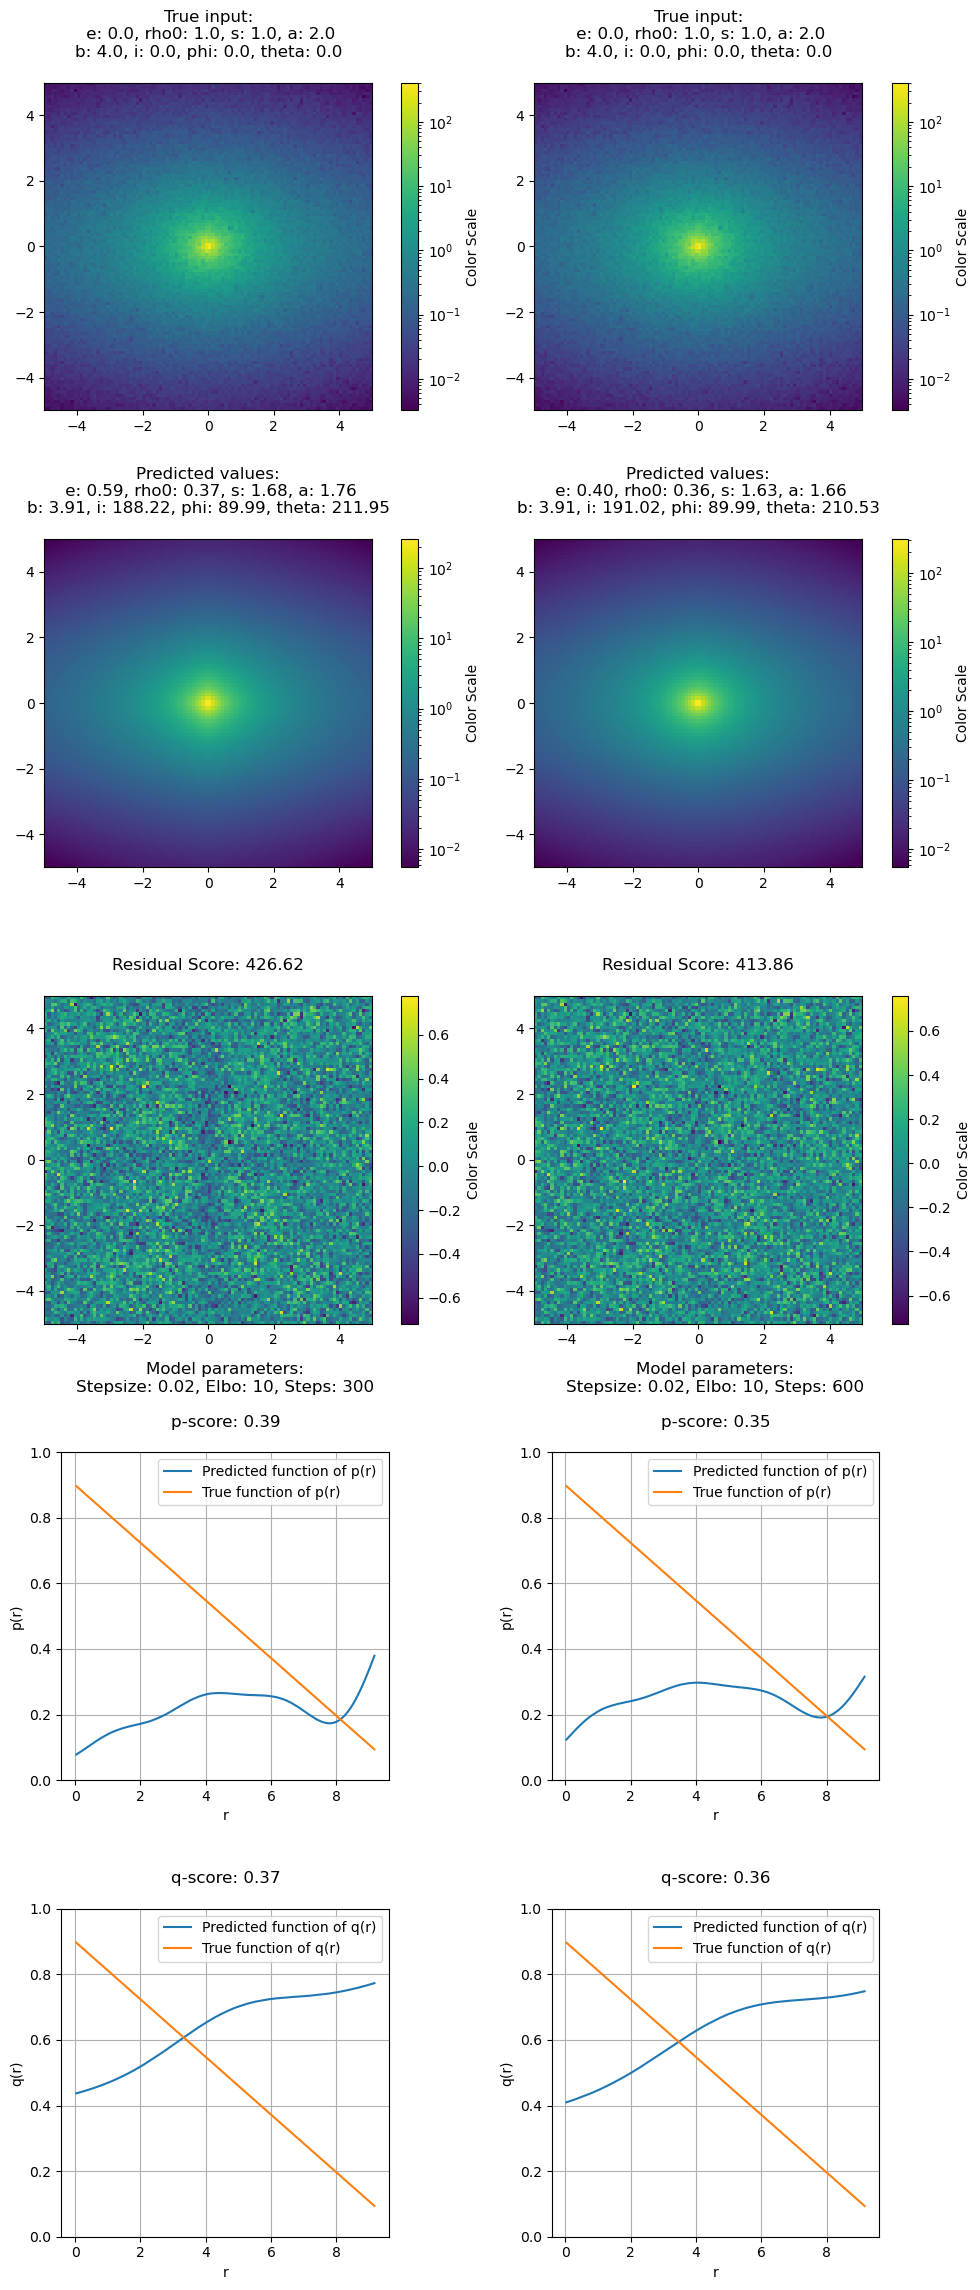

In [23]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    q0 = numpyro.sample('q0', dist.Uniform(0.001,1.)) # i.e. = q(0)
    q5 = numpyro.sample('q5', dist.Uniform(0.001,1.)) # i.e. = q(5)
    
    def linear_mean_function_q(r):
        return q0 + ((q5-q0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_q = numpyro.sample("sigma_q", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_q = numpyro.sample("length_scale_q", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    gp_q = GaussianProcess(kernel_q, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    q_not_transformed = numpyro.sample("q_not_transformed", gp_q.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    q= numpyro.deterministic("q", jnp.clip(q_not_transformed+linear_mean_function_q(r_gp), min = 1e-10, max = 1.))
    interpolator_q = RegularGridInterpolator((r_gp,), q, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    q_final = interpolator_q(r)
 
    # Constant parameters
    e = numpyro.deterministic("e",numpyro.sample('e_sample', dist.Uniform(-1.,1.)))
    rho0 = numpyro.deterministic("rho0",numpyro.sample('rho0_sample', dist.Uniform(1e-10,1.)))
    s = numpyro.deterministic("s",numpyro.sample('s_sample', dist.Uniform(0.2,5.)))
    a = numpyro.deterministic("a",numpyro.sample('a_sample', dist.Uniform(1.,5.)))
    b = numpyro.deterministic("b",numpyro.sample('b_sample', dist.Uniform(1.0,5.0)))
    i = numpyro.deterministic("i",numpyro.sample('i_sample', dist.Uniform(0.,360.)))
    phi = numpyro.deterministic("phi",numpyro.sample('phi_sample', dist.Uniform(0.,360.)))
    theta = numpyro.deterministic("theta",numpyro.sample('theta_sample', dist.Uniform(0.,360.)))


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, 0.0, e, 0., 0., 0., p_final, 0., 0., 0., q_final, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_q(r)_e_rho0_s_a_b_i_phi_theta"

fig, axes = plt.subplots(5,2, figsize=(10,23))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)
                
                e_pred = results.params['e_sample_auto_loc']
                rho0_pred = results.params['rho0_sample_auto_loc']
                s_pred = results.params['s_sample_auto_loc']
                a_pred = results.params['a_sample_auto_loc']
                b_pred = results.params['b_sample_auto_loc']
                i_pred = results.params['i_sample_auto_loc']
                phi_pred = results.params['phi_sample_auto_loc']
                theta_pred = results.params['theta_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                q_mean = posterior_predictive_samples['q'].mean(axis=0)
                q_std = posterior_predictive_samples['q'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]

                e_score = float(score_const(e_d_def,e_pred))
                rho0_score = float(score_const(rho0_def,rho0_pred))
                s_score = float(score_const(s_def,s_pred))
                a_score = float(score_const(a_def,a_pred))
                b_score = float(score_const(b_def,b_pred))
                i_score = float(score_const(i_def,i_pred))
                phi_score = float(score_const(phi_def,phi_pred))
                theta_score = float(score_const(theta_def,theta_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
                q_obs = q(r_gp,p1,p2,p3,p4)

                p_score = float(score_r(p_obs,p_mean))
                q_score = float(score_r(q_obs,q_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score+e_score+rho0_score+s_score+a_score+b_score+i_score+phi_score+theta_score
                ph = None

                csv_entry = [model_name,input_p,input_q,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,e_d_def,e_pred,rho0_def,rho0_pred,rho0_score,s_def,s_pred,s_score,
                             a_def,a_pred,a_score,b_def,b_pred,b_score,i_def,i_pred,i_score,phi_def,phi_pred,phi_score,theta_def,theta_pred,theta_score,p_score,q_score,e_score,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]
                ax5 = axes[4,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n e: {}, rho0: {}, s: {}, a: {}\nb: {}, i: {}, phi: {}, theta: {}\n".format(e_d_def,rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n e: {:.2f}, rho0: {:.2f}, s: {:.2f}, a: {:.2f}\nb: {:.2f}, i: {:.2f}, phi: {:.2f}, theta: {:.2f}\n".format(e_pred,rho0_pred,s_pred,a_pred,b_pred,i_pred,phi_pred,theta_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

                ax5.plot(r_gp, q_mean, label="Predicted function of q(r)")
                ax5.plot(r_gp, q_obs, label="True function of q(r)")
                ax5.legend()
                ax5.set_xlabel('r')
                ax5.set_ylabel('q(r)')
                ax5.grid(True)
                ax5.set_ylim([0,1])
                ax5.set_title("q-score: {:.2f}\n".format(q_score))
                asp = np.diff(ax5.get_xlim())[0] / np.diff(ax5.get_ylim())[0]
                ax5.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

In [24]:
import pandas as pd
df = pd.DataFrame(csv_results, columns=["Model Name","Input p","Input q","Input e","Adam Stepsize","Elbo Stepsize","Steps", "q_def","q_pred","e_def","e_pred","rho0_def","rho0_pred","rho0_score","s_def","s_pred","s_score",
                             "a_def","a_pred","a_score","b_def","b_pred","b_score","i_def","i_pred","i_score","phi_def","phi_pred","phi_score","theta_def","theta_pred","theta_score","p_score","q_score","e_score","img_score","total_score"])

In [25]:
df

,Model Name,Input p,Input q,Input e,Adam Stepsize,Elbo Stepsize,Steps,q_def,q_pred,e_def,...,phi_pred,phi_score,theta_def,theta_pred,theta_score,p_score,q_score,e_score,img_score,total_score
0,p(r)_q(r),linear_decline,linear_decline,None,0.02,10,300,None,None,NaN,...,None,NaN,NaN,None,NaN,0.108615,0.232265,NaN,405.318604,405.659484
1,p(r)_q(r),linear_decline,linear_decline,None,0.02,10,600,None,None,NaN,...,None,NaN,NaN,None,NaN,0.085246,0.172692,NaN,406.621826,406.879764
2,p(r)_q(r)_e,linear_decline,linear_decline,None,0.02,10,300,None,None,0.0,...,None,NaN,NaN,None,NaN,0.109945,0.257822,0.076216,409.128784,409.572767
3,p(r)_q(r)_e,linear_decline,linear_decline,None,0.02,10,600,None,None,0.0,...,None,NaN,NaN,None,NaN,0.091716,0.220391,0.061806,407.946716,408.320629
4,p(r)_q(r)_e_rho0,linear_decline,linear_decline,None,0.02,10,300,None,None,0.0,...,None,NaN,NaN,None,NaN,0.119659,0.373763,0.087228,421.622101,422.363031
5,p(r)_q(r)_e_rho0,linear_decline,linear_decline,None,0.02,10,600,None,None,0.0,...,None,NaN,NaN,None,NaN,0.109996,0.342851,0.097830,417.073608,417.772506
6,p(r)_q(r)_e_rho0_s,linear_decline,linear_decline,None,0.02,10,300,None,None,0.0,...,None,NaN,NaN,None,NaN,0.082828,0.200758,0.648137,564.825439,567.075426
7,p(r)_q(r)_e_rho0_s,linear_decline,linear_decline,None,0.02,10,600,None,None,0.0,...,None,NaN,NaN,None,NaN,0.029955,0.225525,0.102656,416.260101,417.712883
8,p(r)_q(r)_e_rho0_s_a,linear_decline,linear_decline,None,0.02,10,300,None,None,0.0,...,None,NaN,NaN,None,NaN,0.083841,0.204057,0.672899,581.424866,583.787661
9,p(r)_q(r)_e_rho0_s_a,linear_decline,linear_decline,None,0.02,10,600,None,None,0.0,...,None,NaN,NaN,None,NaN,0.029818,0.186407,0.085248,410.391357,412.006126


In [26]:
df.to_pickle("Z:\\Uni\\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\pq\\table\\"+input_p+"_"+model_name+".pkl")